In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm
import jax
import random

from JAX_Deprojection import surface_brightness as sb
from JAX_Deprojection import density_distribution as den

In [2]:
s_def = 1. 
e_def = 0.
p_def = 0.5
q_def = 0.6
a_def = 2.
b_def = 4.
rho0_def = 0.001
i_def = 0.
phi_def = 0.
theta_def = 0.

size = 100
extent = 1
extents = [-extent, extent,-extent, extent]

Optimzer route:  [Array(0.5, dtype=float32), Array(0.1, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32), Array(0.31143168, dtype=float32), Array(0.25620013, dtype=float32), Array(0.24502908, dtype=float32), Array(0.2502041, dtype=float32), Array(0.25000665, dtype=float32), Array(0.24999999, dtype=float32), Array(0.25000003, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32), Array(1., dtype=float32), Array(0.8760423, dtype=float32), Array(0.7763417, dtype=float32), Array(0.7419142, dtype=float32), Array(0.7504652, dtype=float32), Array(0.750008, dtype=float32), Array(0.74999994, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32), Array(1., dtype=float32)]


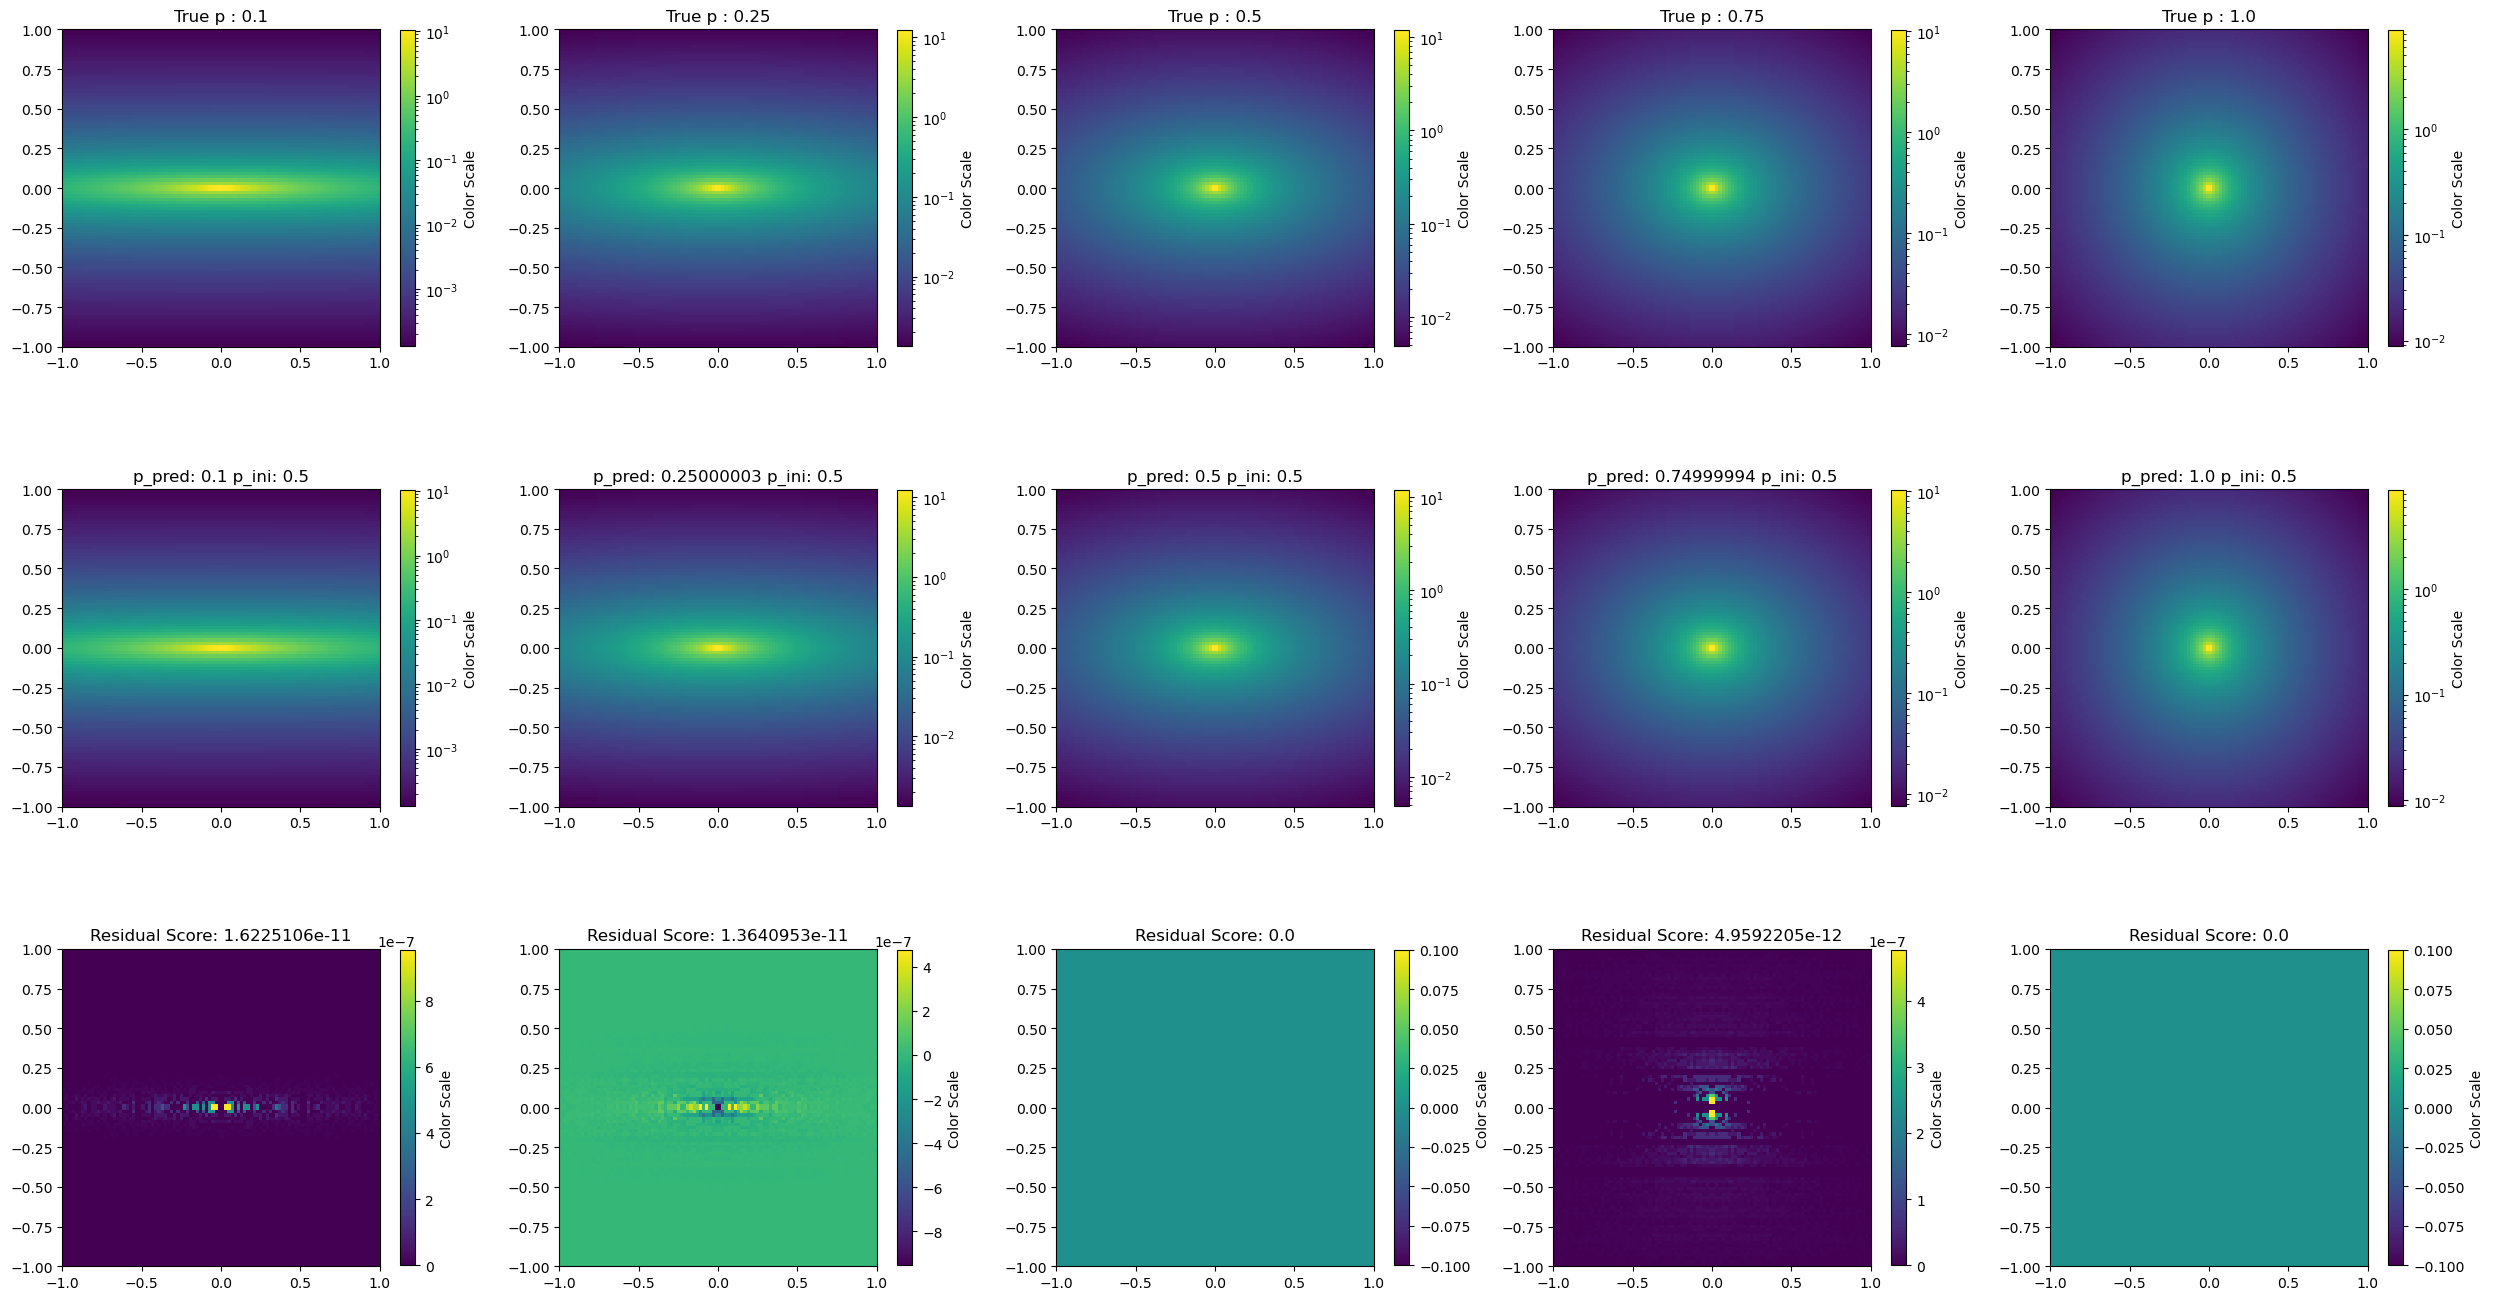

In [3]:
# varying over different p values

p = [0.1,0.25,0.5,0.75,1.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p[j], q_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True p : "+str(p[j]))

    bounds = (p[0], p[-1])
    starting_guess = p_def #random.uniform(p[0], p[-1])
    initial_params = [e_def,starting_guess,q_def,rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def]
    optimize_mask = [False,True,False,False,False,False,False,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("p_pred: "+str(res[-1])+" p_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(0.6, dtype=float32), Array(0.1, dtype=float32)]
Optimzer route:  [Array(0.6, dtype=float32), Array(0.24343592, dtype=float32), Array(0.25091633, dtype=float32), Array(0.25005087, dtype=float32), Array(0.24999945, dtype=float32), Array(0.24999997, dtype=float32)]
Optimzer route:  [Array(0.6, dtype=float32), Array(0.5376275, dtype=float32), Array(0.5056578, dtype=float32), Array(0.4973885, dtype=float32), Array(0.5001476, dtype=float32), Array(0.50000364, dtype=float32), Array(0.50000006, dtype=float32)]
Optimzer route:  [Array(0.6, dtype=float32), Array(1., dtype=float32), Array(0.90371597, dtype=float32), Array(0.71877044, dtype=float32), Array(0.7702752, dtype=float32), Array(0.753319, dtype=float32), Array(0.7496543, dtype=float32), Array(0.750006, dtype=float32), Array(0.749999, dtype=float32)]
Optimzer route:  [Array(0.6, dtype=float32), Array(1., dtype=float32)]


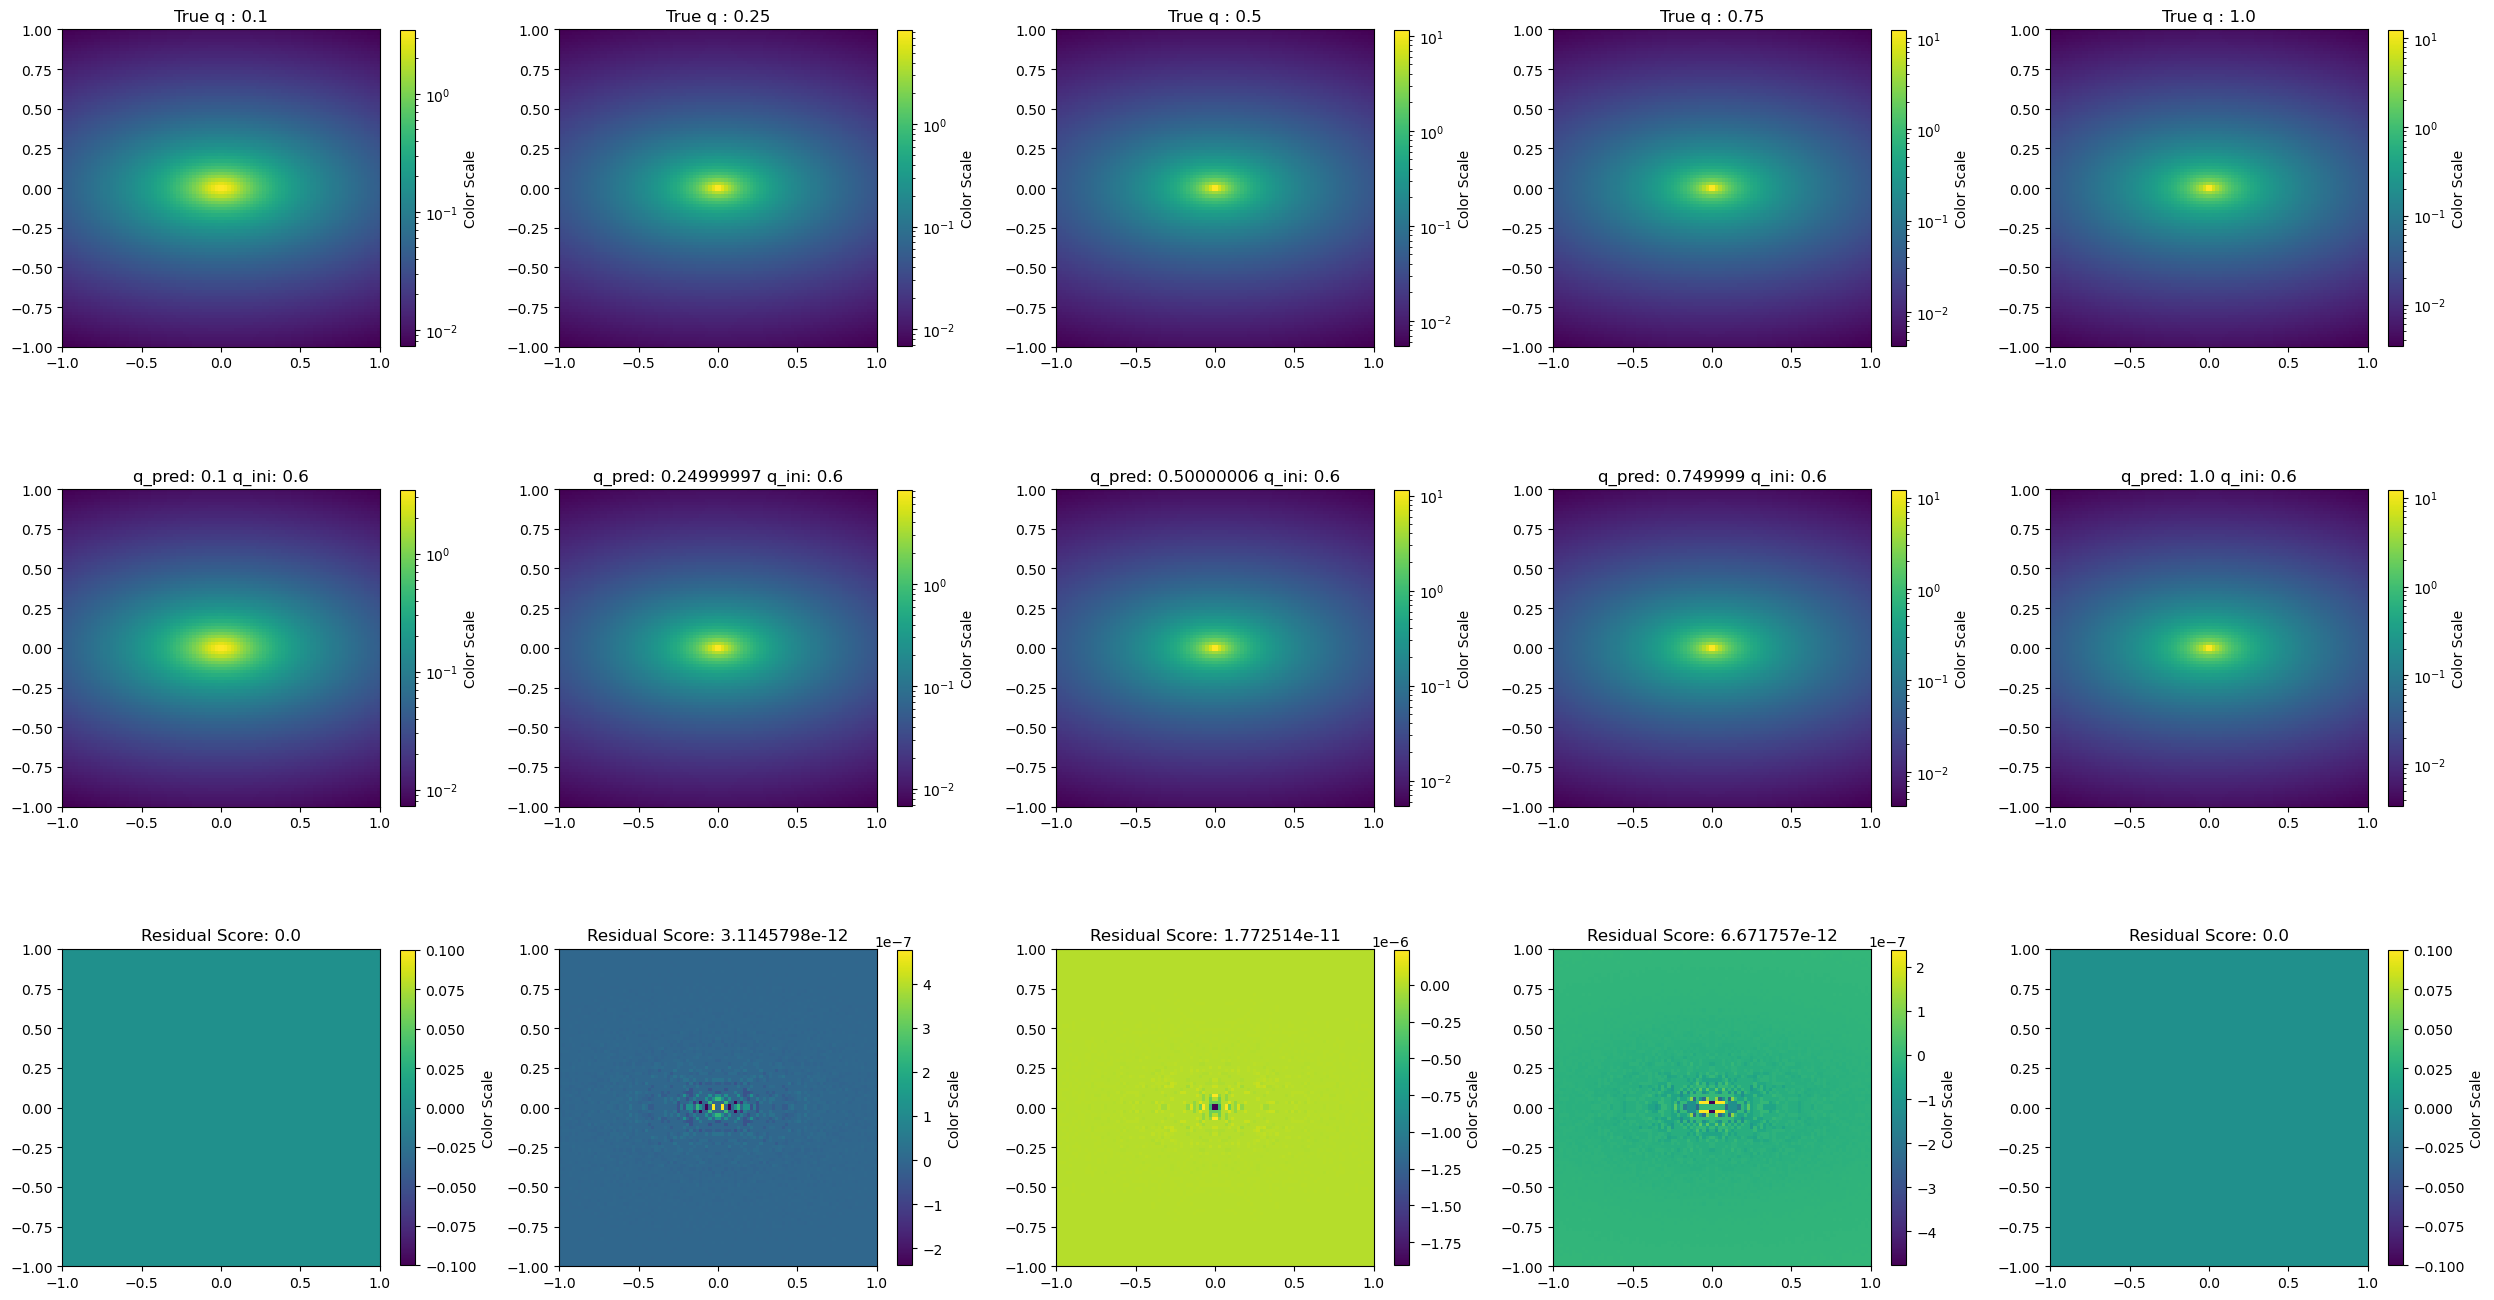

In [4]:
# varying over different p values

q = [0.1,0.25,0.5,0.75,1.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q[j], rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True q : "+str(q[j]))

    bounds = (q[0], q[-1])
    starting_guess = q_def #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,starting_guess,rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def]
    optimize_mask = [False,False,True,False,False,False,False,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("q_pred: "+str(res[-1])+" q_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(0., dtype=float32), Array(-1., dtype=float32)]
Optimzer route:  [Array(0., dtype=float32), Array(-1., dtype=float32), Array(-0.7552639, dtype=float32), Array(-0.51105183, dtype=float32), Array(-0.49639392, dtype=float32), Array(-0.5000449, dtype=float32), Array(-0.5000006, dtype=float32)]
Optimzer route:  [Array(0., dtype=float32)]
Optimzer route:  [Array(0., dtype=float32), Array(0.4328665, dtype=float32), Array(0.4952296, dtype=float32), Array(0.50040036, dtype=float32), Array(0.49999744, dtype=float32), Array(0.4999998, dtype=float32), Array(0.49999994, dtype=float32)]
Optimzer route:  [Array(0., dtype=float32), Array(1., dtype=float32)]


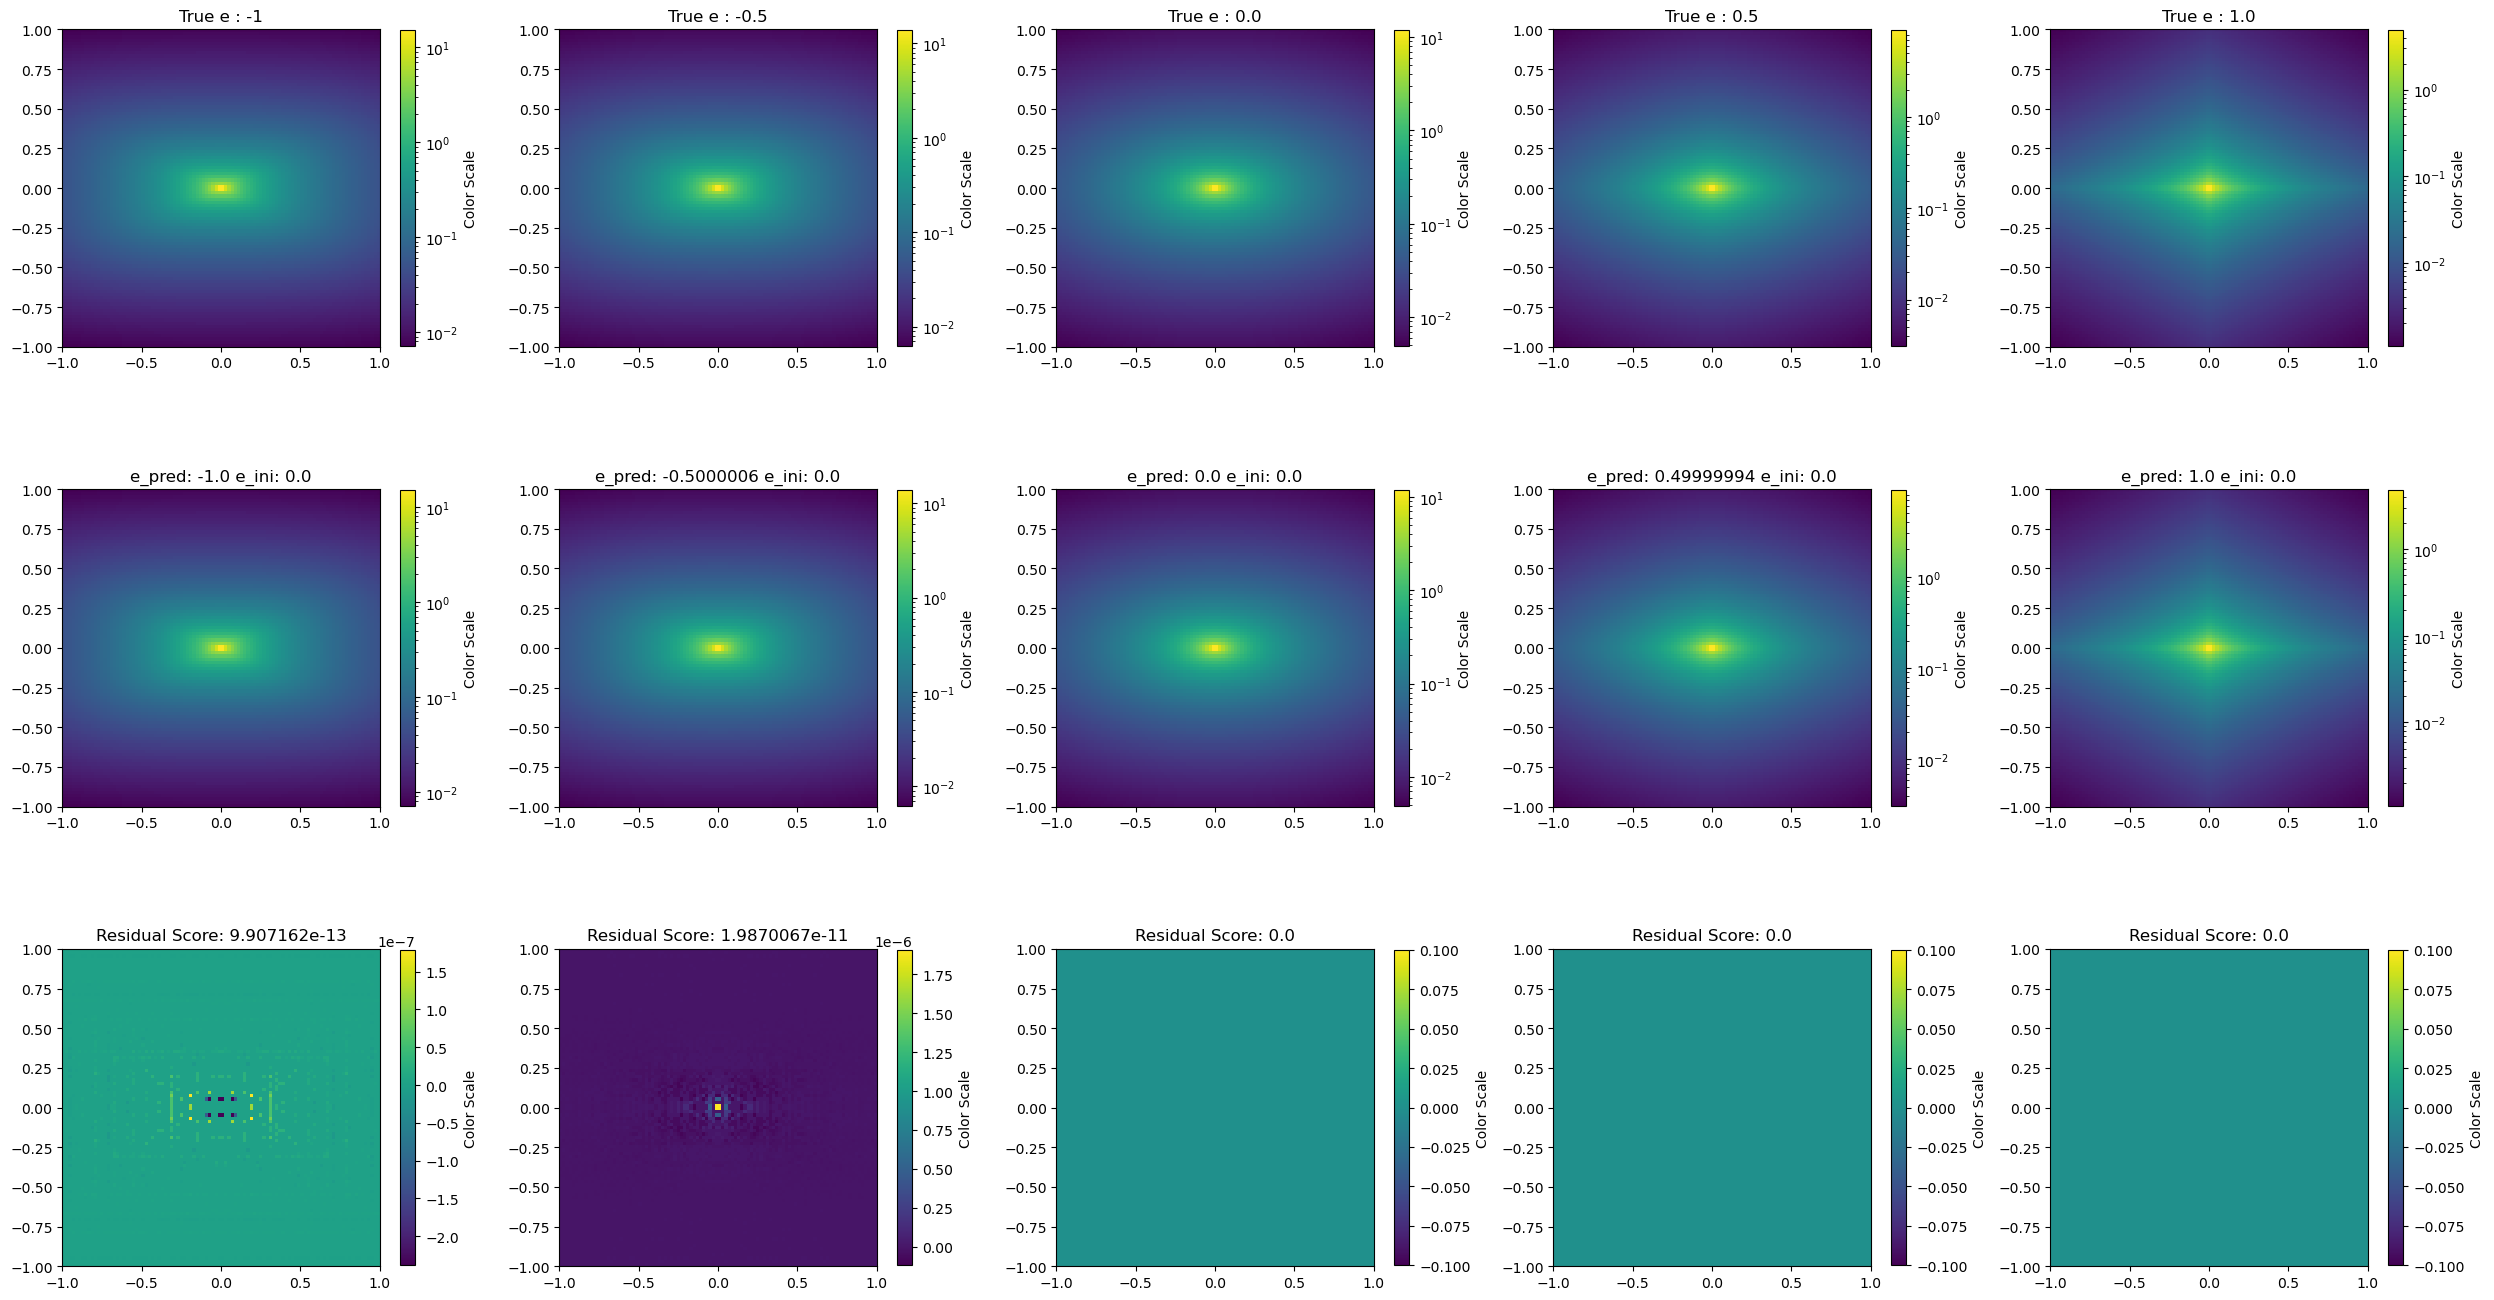

In [5]:
# varying over different p values

e = [-1,-0.5,0.,0.5,1.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e[j], p_def, q_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True e : "+str(e[j]))

    bounds = (e[0], e[-1])
    starting_guess = e_def #random.uniform(p[0], p[-1])
    initial_params = [starting_guess,p_def,q_def,rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def]
    optimize_mask = [True,False,False,False,False,False,False,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("e_pred: "+str(res[-1])+" e_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(0.001, dtype=float32)]
Optimzer route:  [Array(0.001, dtype=float32), Array(0.01, dtype=float32), Array(0.01, dtype=float32)]
Optimzer route:  [Array(0.001, dtype=float32), Array(0.10000003, dtype=float32), Array(0.09999999, dtype=float32), Array(0.1, dtype=float32)]
Optimzer route:  [Array(0.001, dtype=float32), Array(1.0000001, dtype=float32)]
Optimzer route:  [Array(0.001, dtype=float32), Array(10., dtype=float32)]


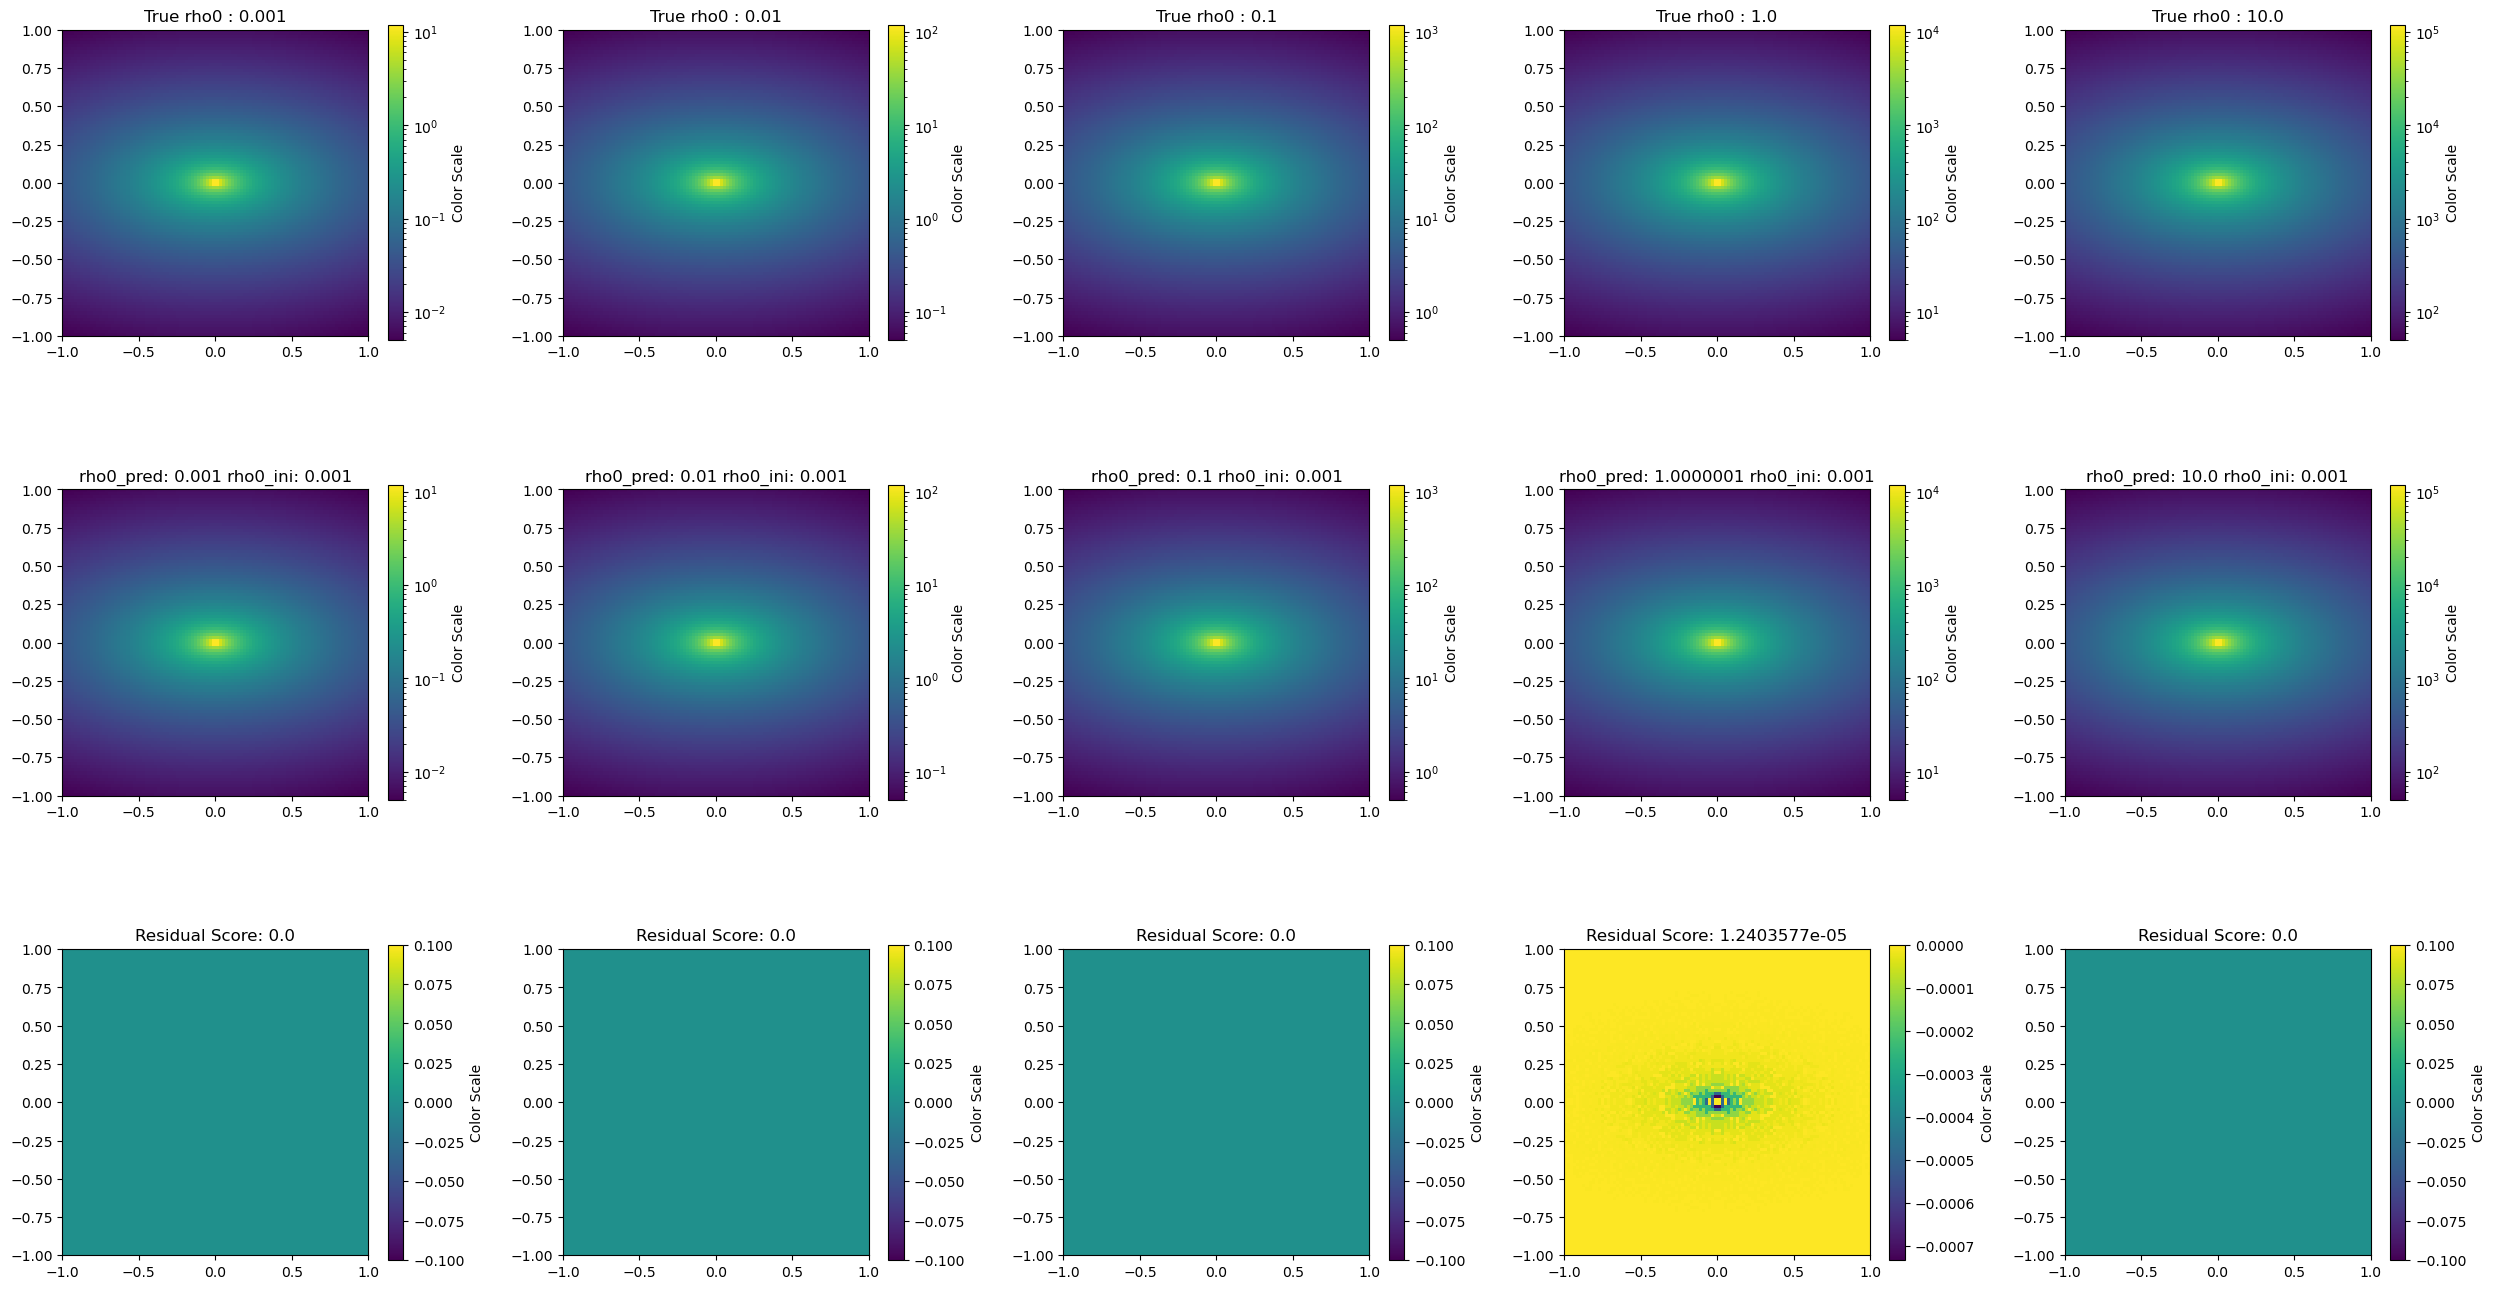

In [6]:
# varying over different p values

rho0 = [0.001,0.01,0.1,1.,10.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q_def, rho0[j], s_def, a_def, b_def, i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True rho0 : "+str(rho0[j]))

    bounds = (rho0[0], rho0[-1])
    starting_guess = rho0_def #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,q_def,starting_guess,s_def,a_def,b_def,i_def,phi_def,theta_def]
    optimize_mask = [False,False,False,True,False,False,False,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("rho0_pred: "+str(res[-1])+" rho0_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(1., dtype=float32), Array(0.01, dtype=float32)]
Optimzer route:  [Array(1., dtype=float32), Array(0.01, dtype=float32), Array(0.09966983, dtype=float32), Array(0.09995462, dtype=float32), Array(0.10000034, dtype=float32), Array(0.09999999, dtype=float32)]
Optimzer route:  [Array(1., dtype=float32)]
Optimzer route:  [Array(1., dtype=float32), Array(10.248852, dtype=float32), Array(9.992224, dtype=float32), Array(9.999708, dtype=float32), Array(10.000001, dtype=float32), Array(10., dtype=float32)]
Optimzer route:  [Array(1., dtype=float32), Array(100., dtype=float32)]


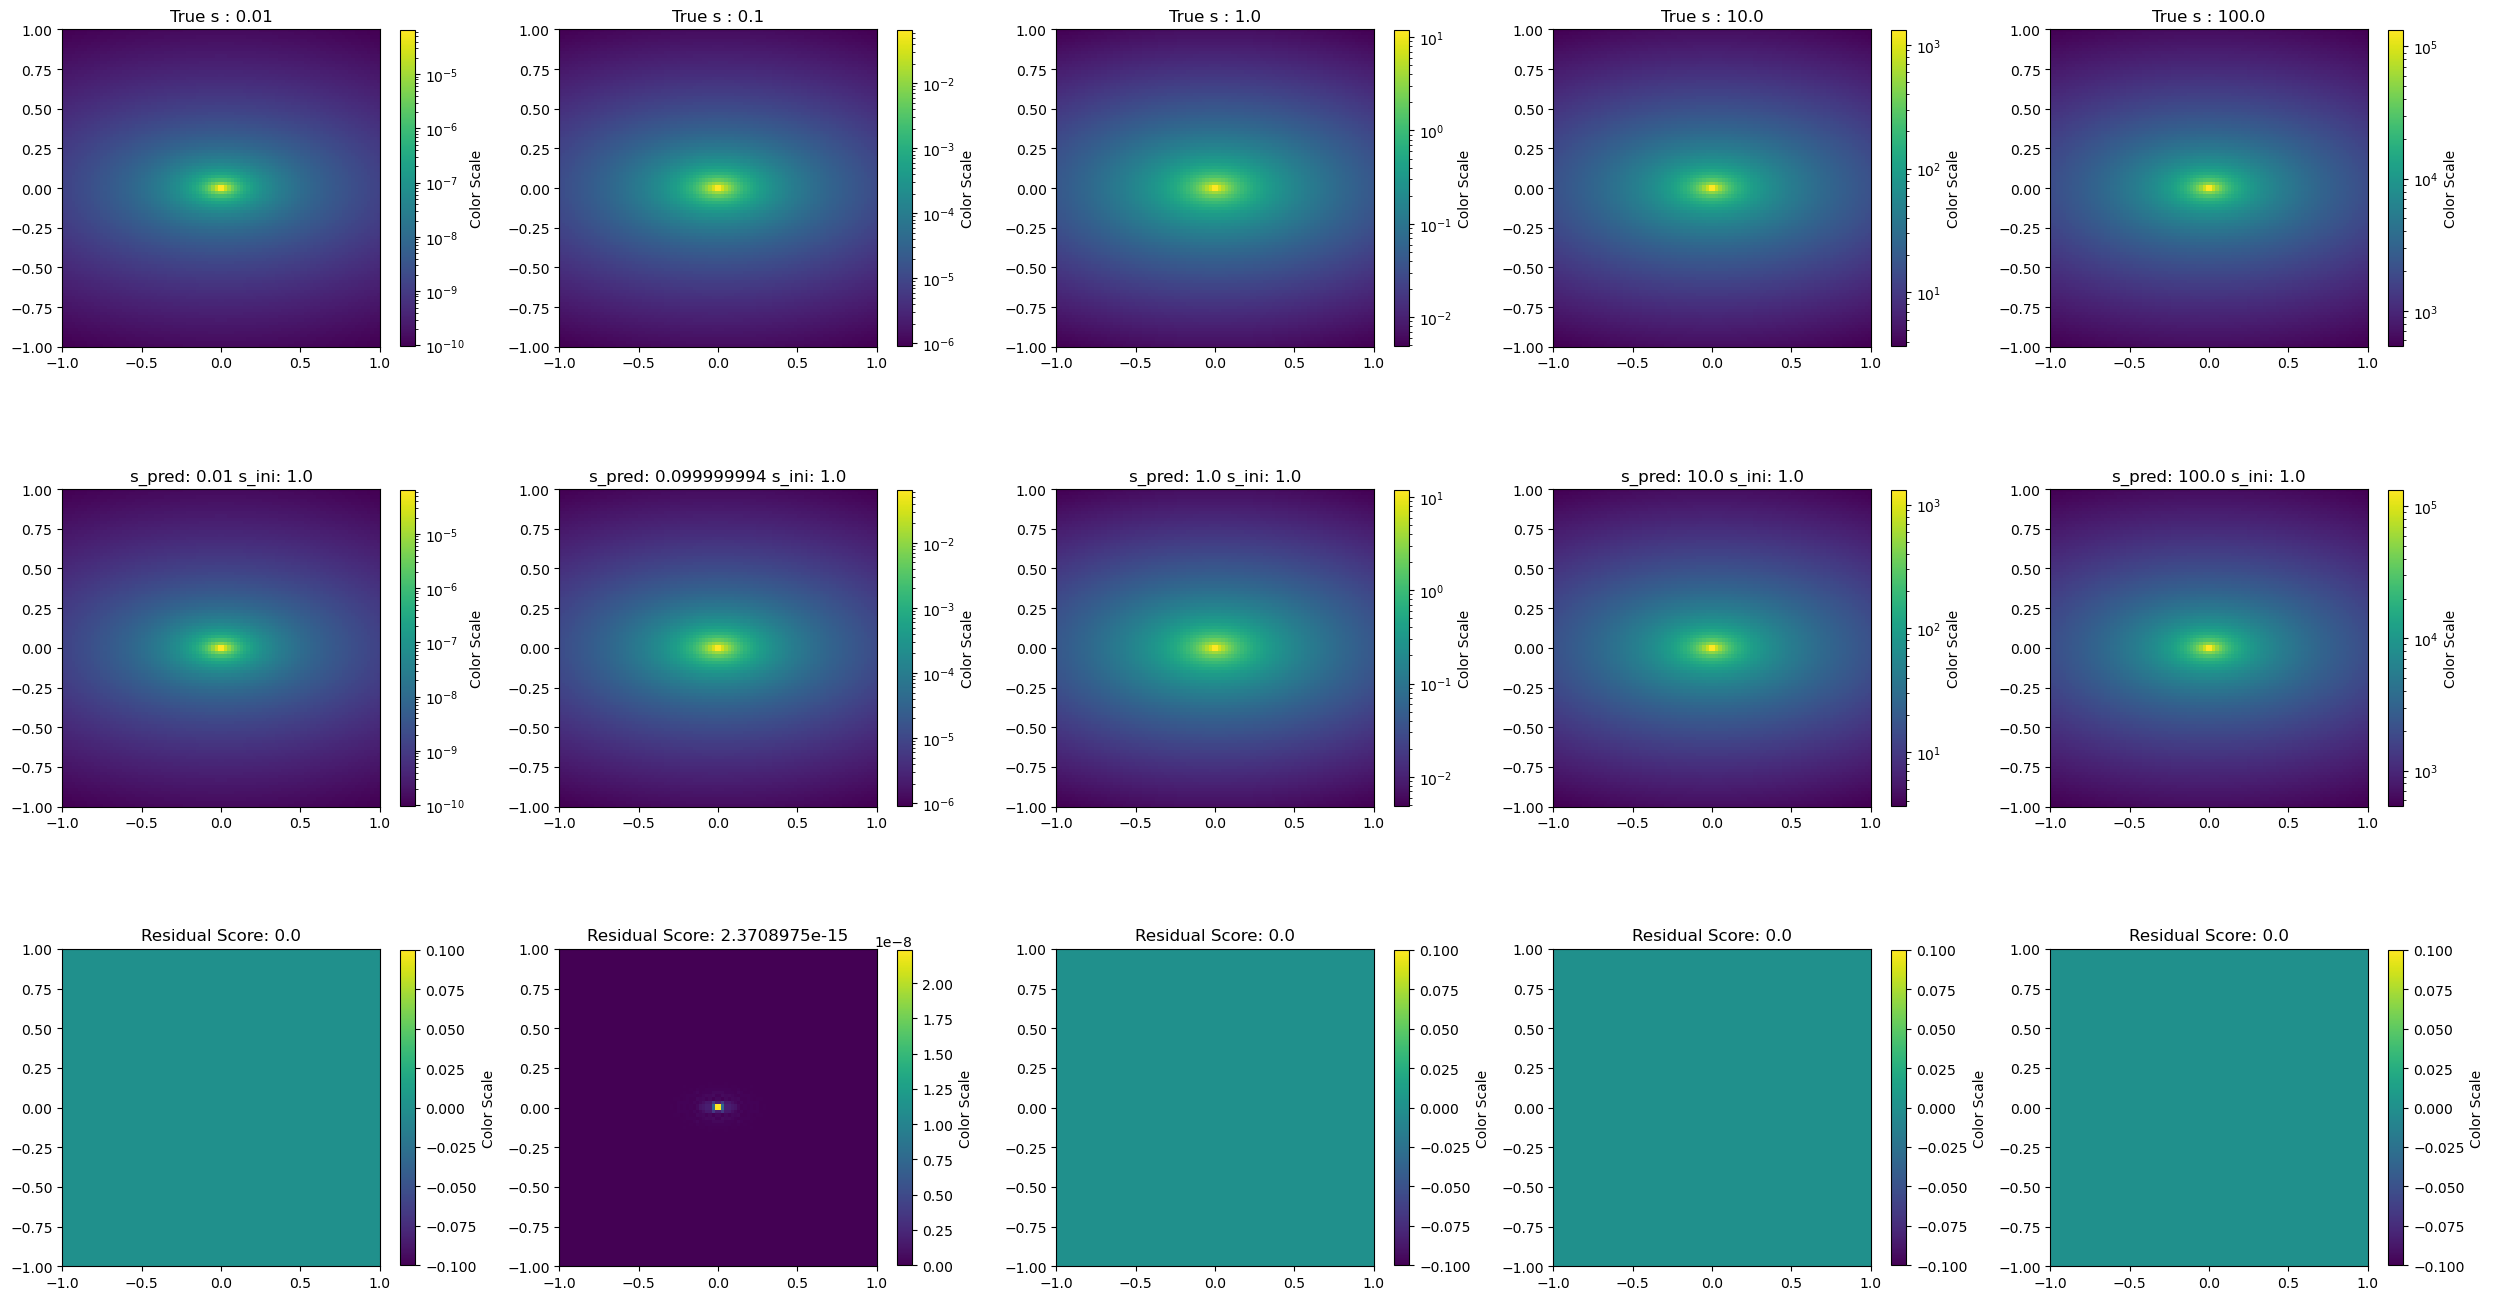

In [7]:
# varying over different p values

s = [0.01,0.1,1.,10.,100.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q_def, rho0_def, s[j], a_def, b_def, i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True s : "+str(s[j]))

    bounds = (s[0], s[-1])
    starting_guess = s_def #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,q_def,rho0_def,starting_guess,a_def,b_def,i_def,phi_def,theta_def]
    optimize_mask = [False,False,False,False,True,False,False,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("s_pred: "+str(res[-1])+" s_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(2., dtype=float32), Array(0., dtype=float32)]
Optimzer route:  [Array(2., dtype=float32), Array(0., dtype=float32), Array(0.96418834, dtype=float32), Array(0.9968176, dtype=float32), Array(1.0003554, dtype=float32), Array(0.99999666, dtype=float32), Array(1., dtype=float32)]
Optimzer route:  [Array(2., dtype=float32)]
Optimzer route:  [Array(2., dtype=float32), Array(2.954029, dtype=float32), Array(3.0002623, dtype=float32), Array(2.9999309, dtype=float32), Array(3., dtype=float32)]
Optimzer route:  [Array(2., dtype=float32), Array(4., dtype=float32)]


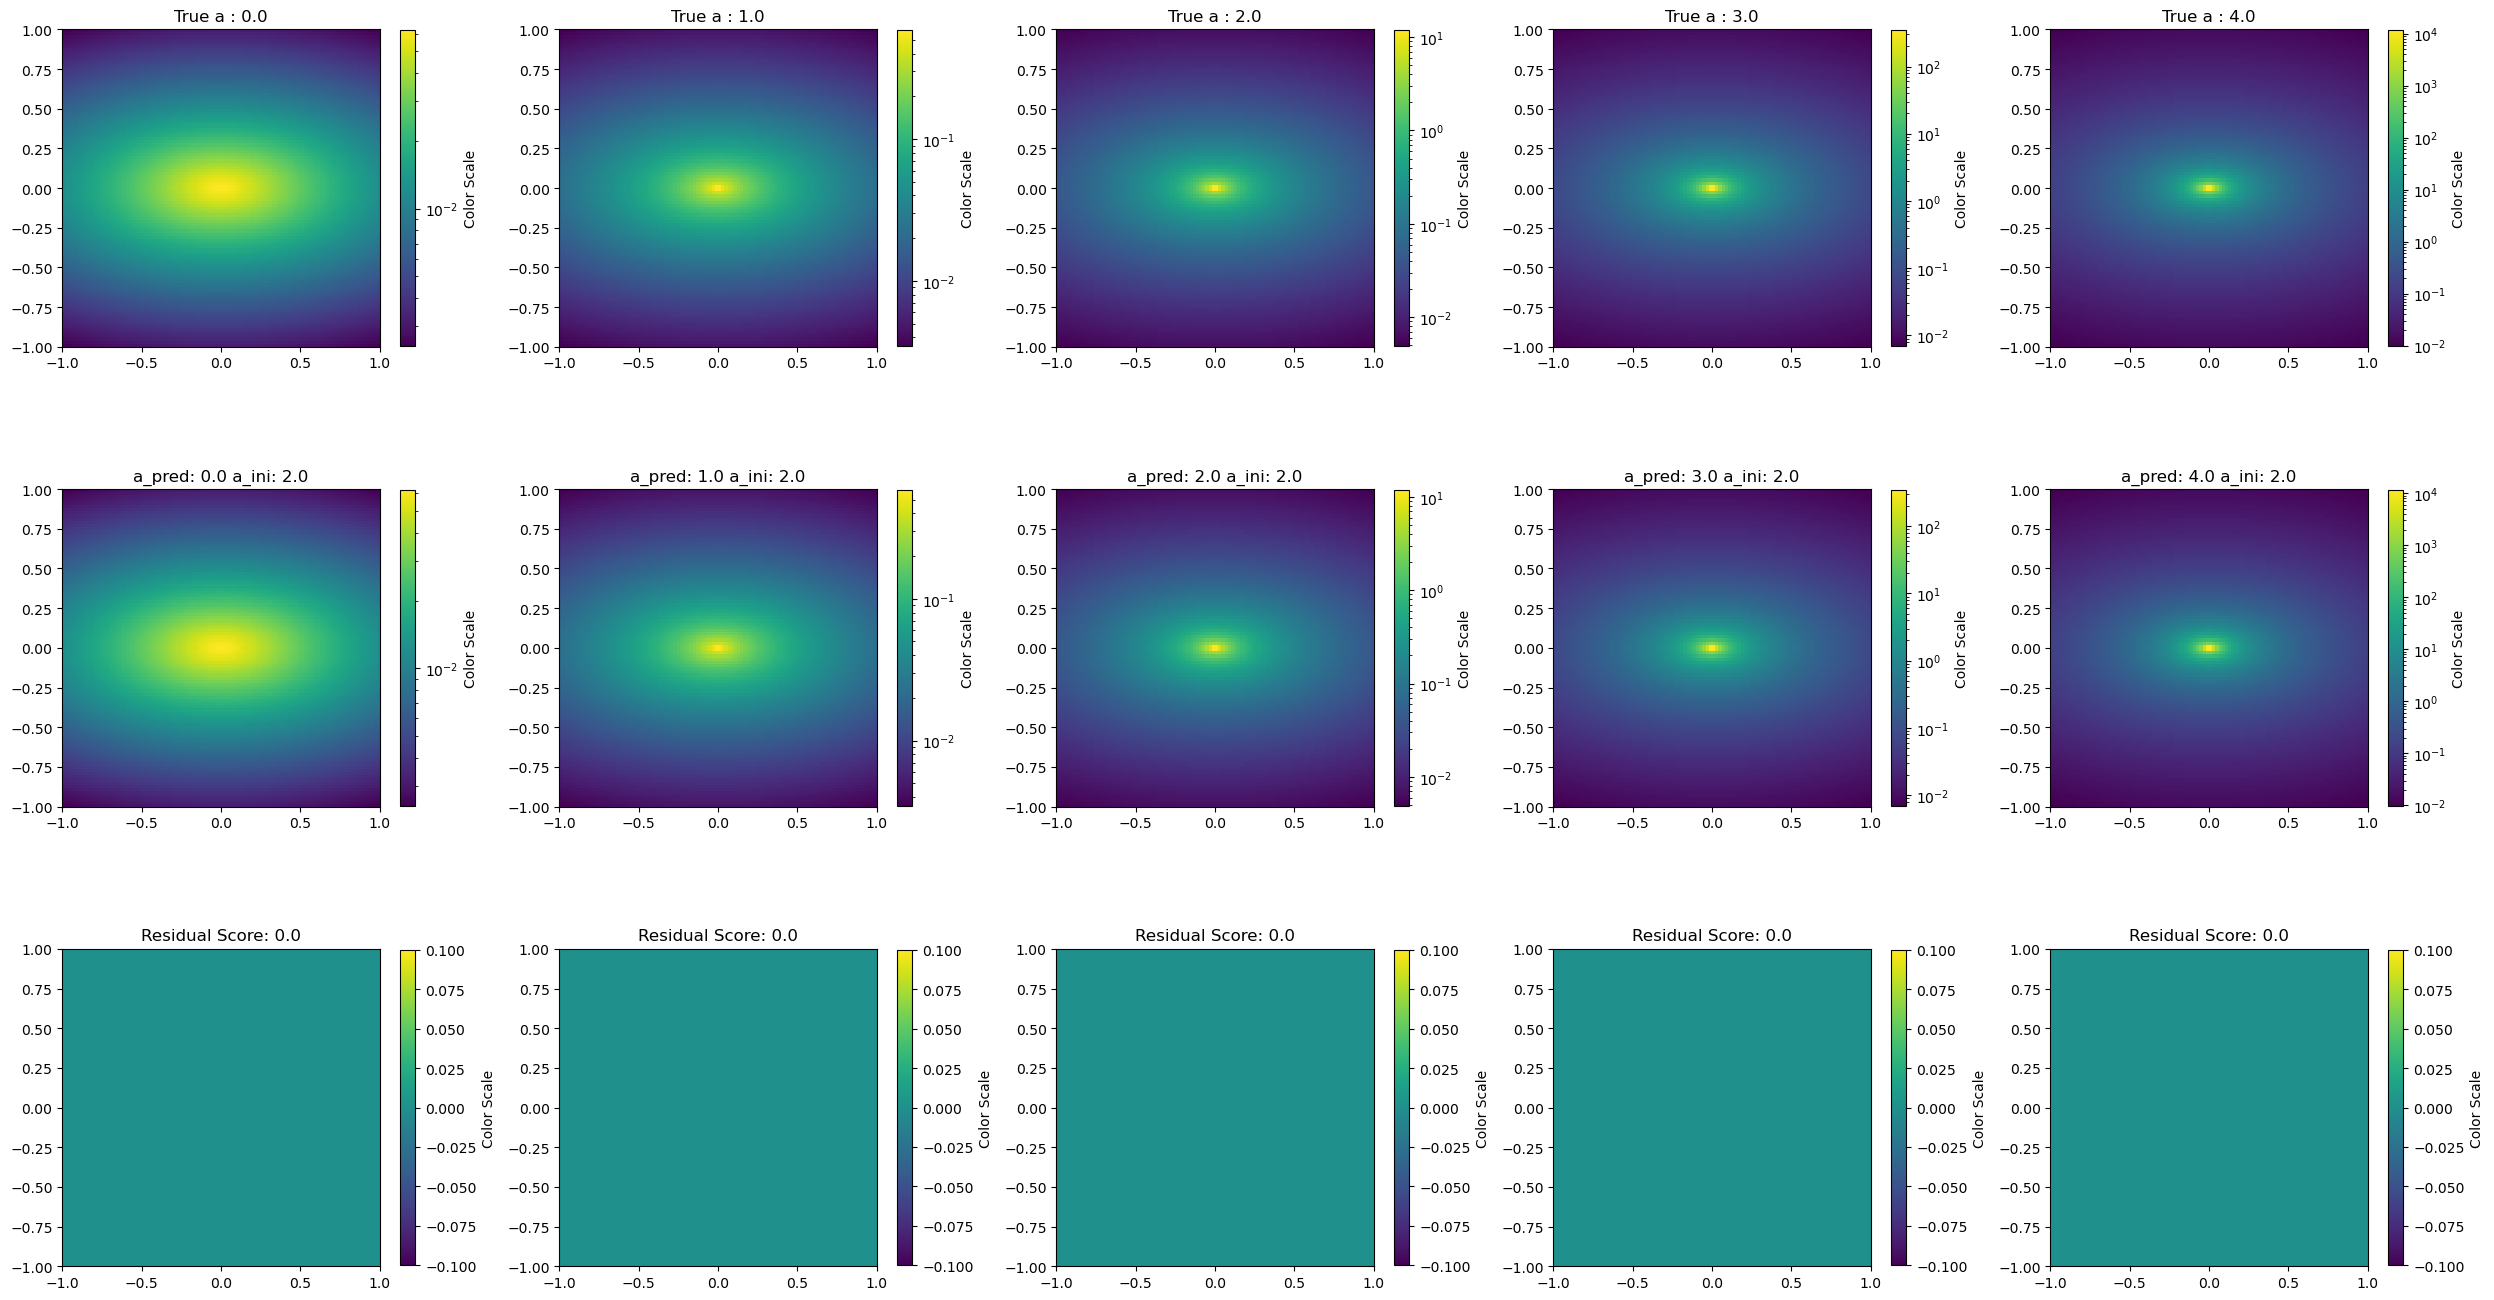

In [8]:
# varying over different p values

a = [0.,1.,2.,3.,4.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q_def, rho0_def, s_def, a[j], b_def, i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True a : "+str(a[j]))

    bounds = (a[0], a[-1])
    starting_guess = a_def #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,q_def,rho0_def,s_def,starting_guess,b_def,i_def,phi_def,theta_def]
    optimize_mask = [False,False,False,False,False,True,False,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("a_pred: "+str(res[-1])+" a_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(4., dtype=float32), Array(0., dtype=float32)]
Optimzer route:  [Array(4., dtype=float32), Array(0.96832603, dtype=float32), Array(1.0014929, dtype=float32), Array(1.0000544, dtype=float32), Array(0.9999999, dtype=float32), Array(1., dtype=float32)]
Optimzer route:  [Array(4., dtype=float32), Array(2.1010082, dtype=float32), Array(2.0099857, dtype=float32), Array(1.9989542, dtype=float32), Array(2.0000105, dtype=float32), Array(1.9999999, dtype=float32), Array(2., dtype=float32)]
Optimzer route:  [Array(4., dtype=float32), Array(2.8945582, dtype=float32), Array(3.1063464, dtype=float32), Array(3.0089998, dtype=float32), Array(2.9992037, dtype=float32), Array(3.0000057, dtype=float32), Array(3., dtype=float32)]
Optimzer route:  [Array(4., dtype=float32)]


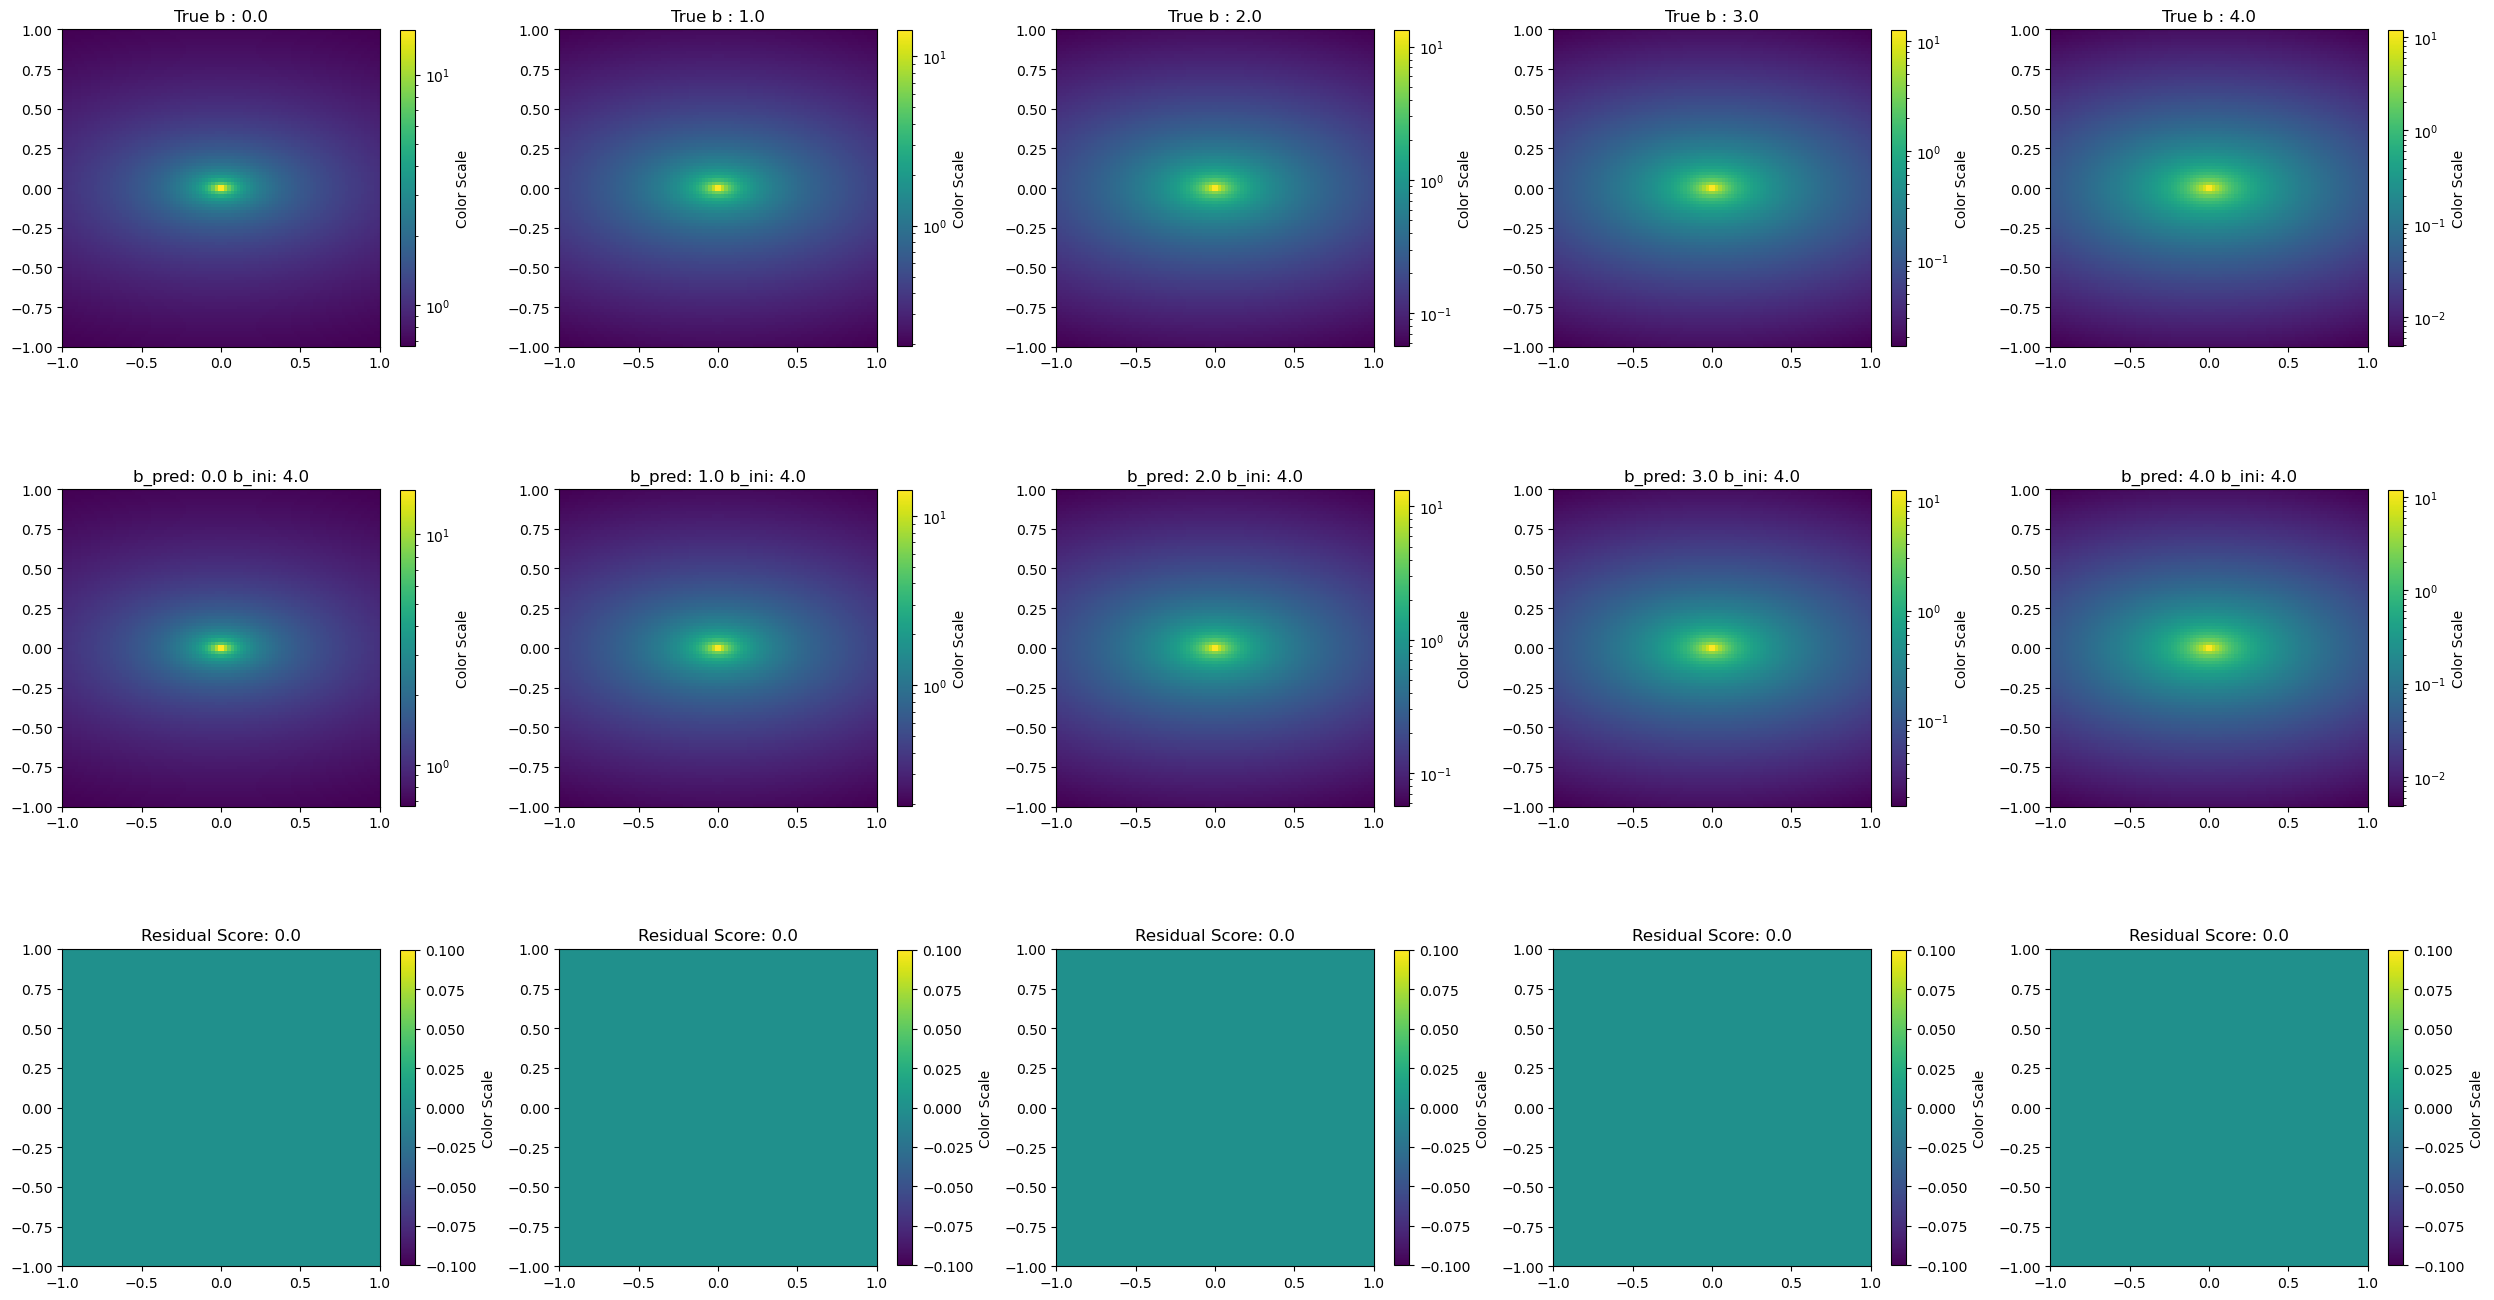

In [9]:
# varying over different p values

b = [0.,1.,2.,3.,4.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q_def, rho0_def, s_def, a_def, b[j], i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True b : "+str(b[j]))

    bounds = (b[0], b[-1])
    starting_guess = b_def #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,q_def,rho0_def,s_def,a_def,starting_guess,i_def,phi_def,theta_def]
    optimize_mask = [False,False,False,False,False,False,True,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("b_pred: "+str(res[-1])+" b_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(10., dtype=float32), Array(9.994036, dtype=float32), Array(6.5533834, dtype=float32), Array(5.153532, dtype=float32), Array(3.8092787, dtype=float32), Array(2.8904111, dtype=float32), Array(2.173963, dtype=float32), Array(1.6418297, dtype=float32), Array(1.2386781, dtype=float32), Array(0.9348346, dtype=float32)]
Optimzer route:  [Array(35., dtype=float32), Array(35.083057, dtype=float32), Array(46.957146, dtype=float32), Array(44.84177, dtype=float32), Array(44.999672, dtype=float32)]
Optimzer route:  [Array(80., dtype=float32), Array(80.00656, dtype=float32), Array(83.39236, dtype=float32), Array(84.81608, dtype=float32), Array(86.16416, dtype=float32), Array(87.090004, dtype=float32), Array(87.81087, dtype=float32), Array(88.34596, dtype=float32), Array(88.753044, dtype=float32), Array(89.05762, dtype=float32)]
Optimzer route:  [Array(125., dtype=float32), Array(125.08686, dtype=float32), Array(136.4071, dtype=float32), Array(134.94661, dtype=float32), Array(

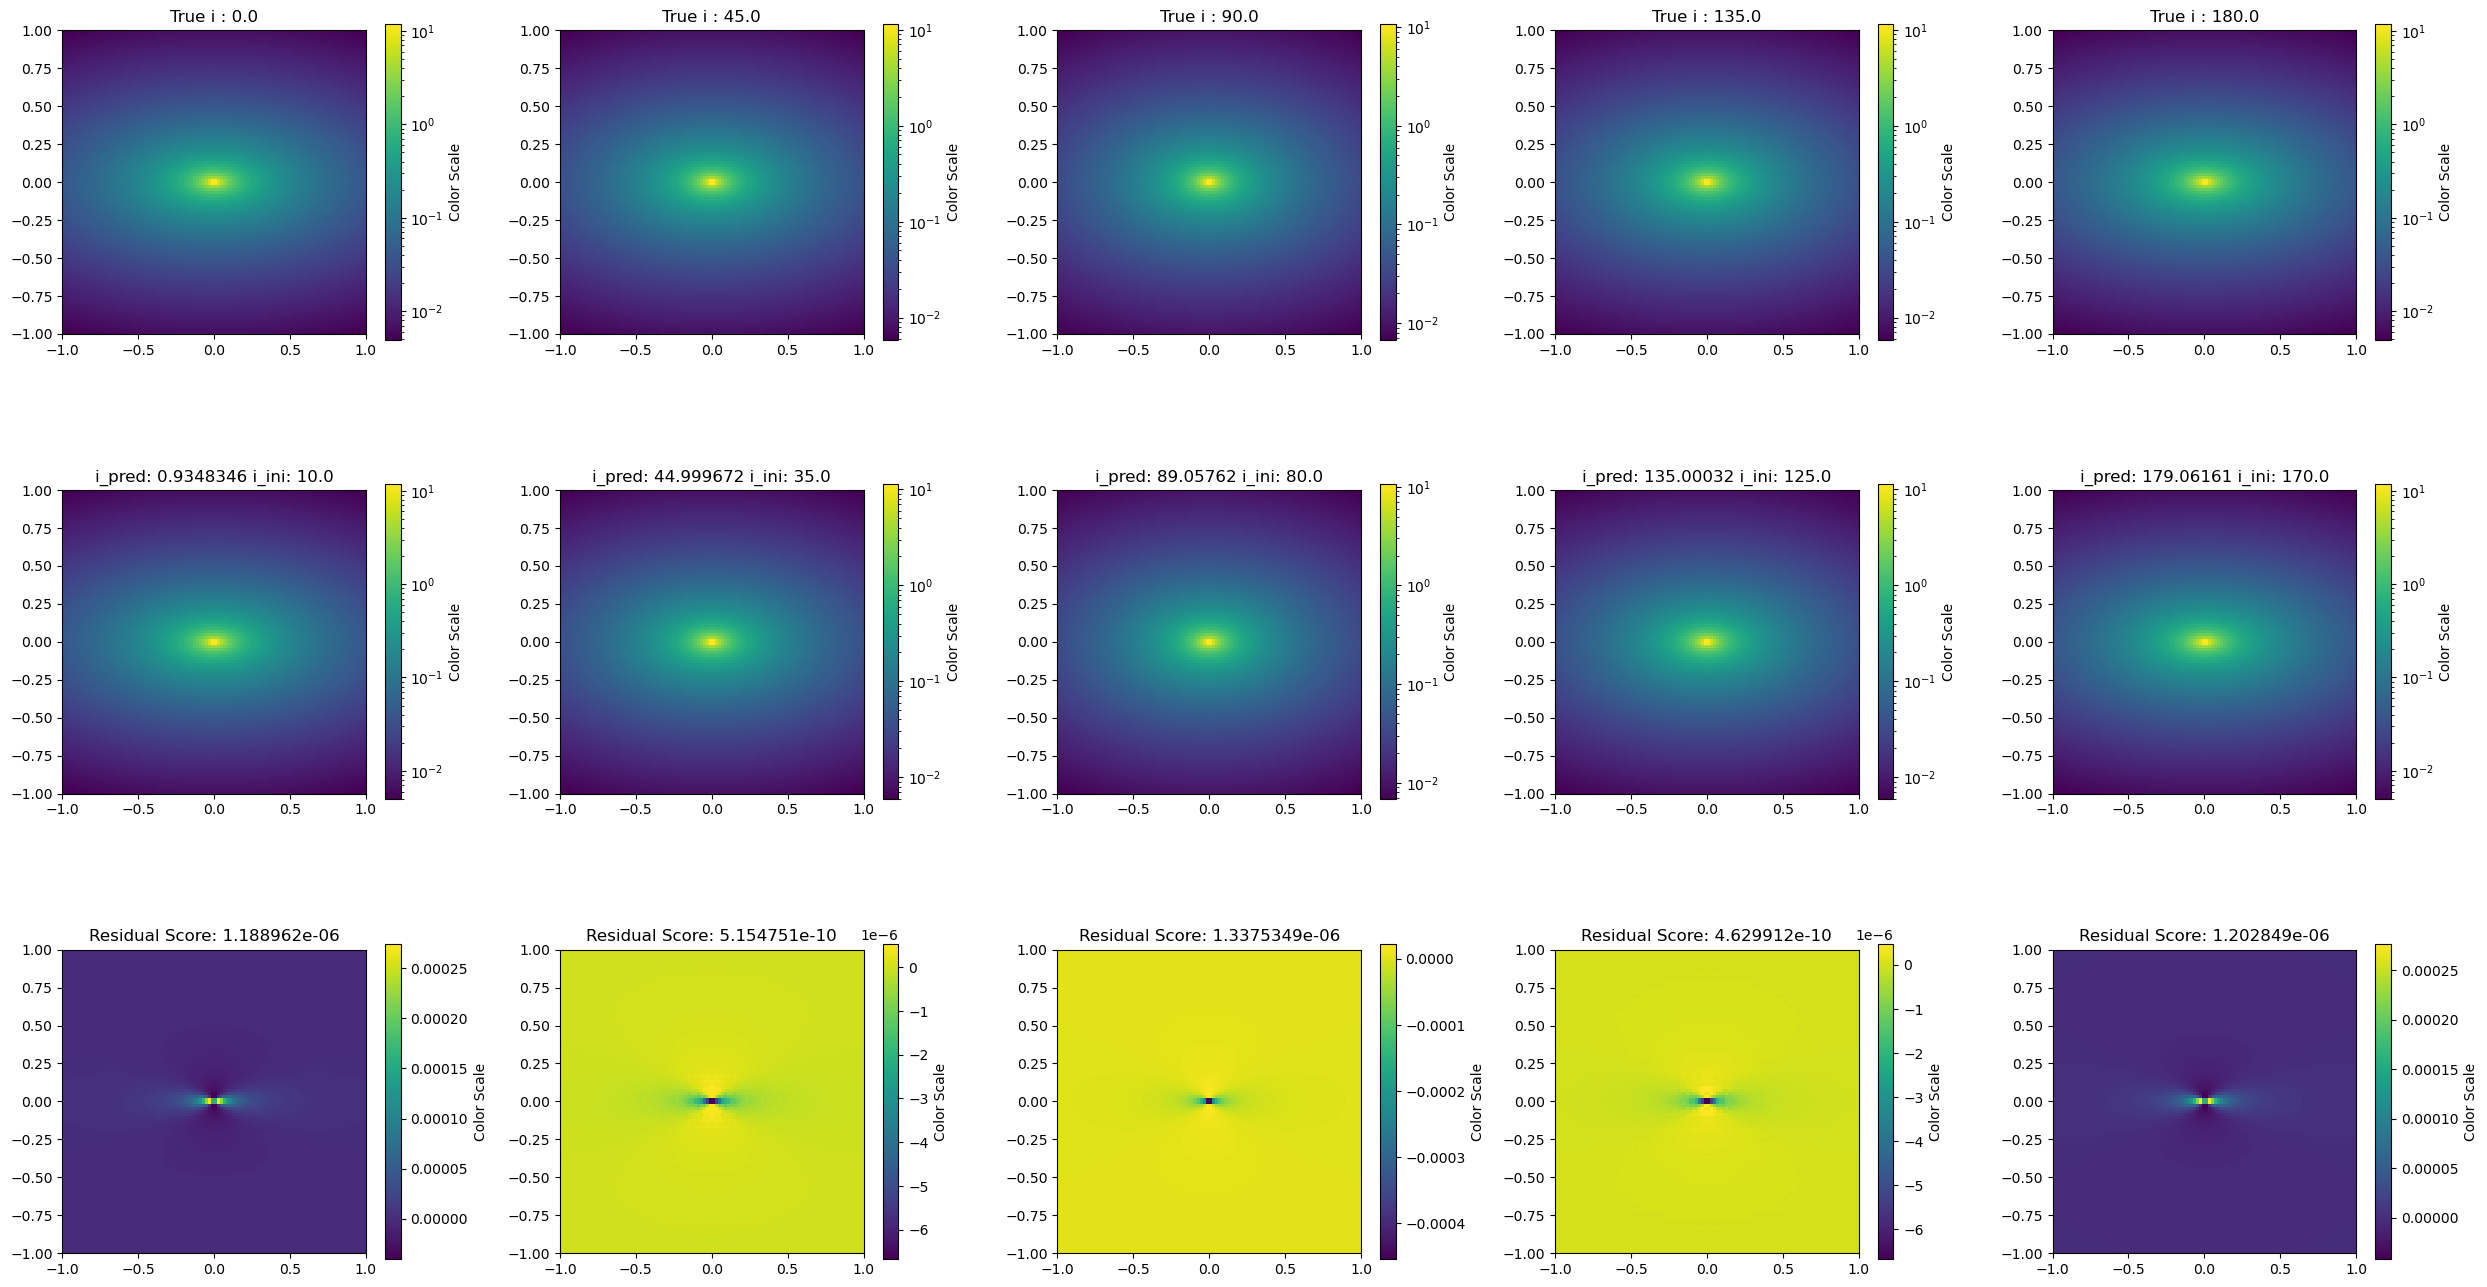

In [10]:
# varying over different p values

i = [0.,45.,90.,135.,180.]

i_guess = [10.,35.,80.,125.,170.]



# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q_def, rho0_def, s_def, a_def, b_def, i[j], phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True i : "+str(i[j]))

    bounds = (i[0], i[-1])
    starting_guess = i_guess[j] #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,q_def,rho0_def,s_def,a_def,b_def,starting_guess,phi_def,theta_def]
    optimize_mask = [False,False,False,False,False,False,False,True,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("i_pred: "+str(res[-1])+" i_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(10., dtype=float32), Array(9.963422, dtype=float32), Array(6.601058, dtype=float32), Array(5.194344, dtype=float32), Array(3.846665, dtype=float32), Array(2.9197767, dtype=float32), Array(2.1972988, dtype=float32), Array(1.6596464, dtype=float32), Array(1.2518252, dtype=float32), Array(0.94547665, dtype=float32), Array(0.71323335, dtype=float32), Array(0.5379938, dtype=float32)]
Optimzer route:  [Array(35., dtype=float32), Array(35.739746, dtype=float32), Array(48.952206, dtype=float32), Array(44.098175, dtype=float32), Array(44.93319, dtype=float32), Array(45.001293, dtype=float32), Array(45.00001, dtype=float32)]
Optimzer route:  [Array(80., dtype=float32), Array(80.181816, dtype=float32), Array(83.64098, dtype=float32), Array(85.04356, dtype=float32), Array(86.34744, dtype=float32), Array(87.23557, dtype=float32), Array(87.92295, dtype=float32), Array(88.43253, dtype=float32), Array(88.81819, dtype=float32), Array(89.107834, dtype=float32), Array(89.3272, dty

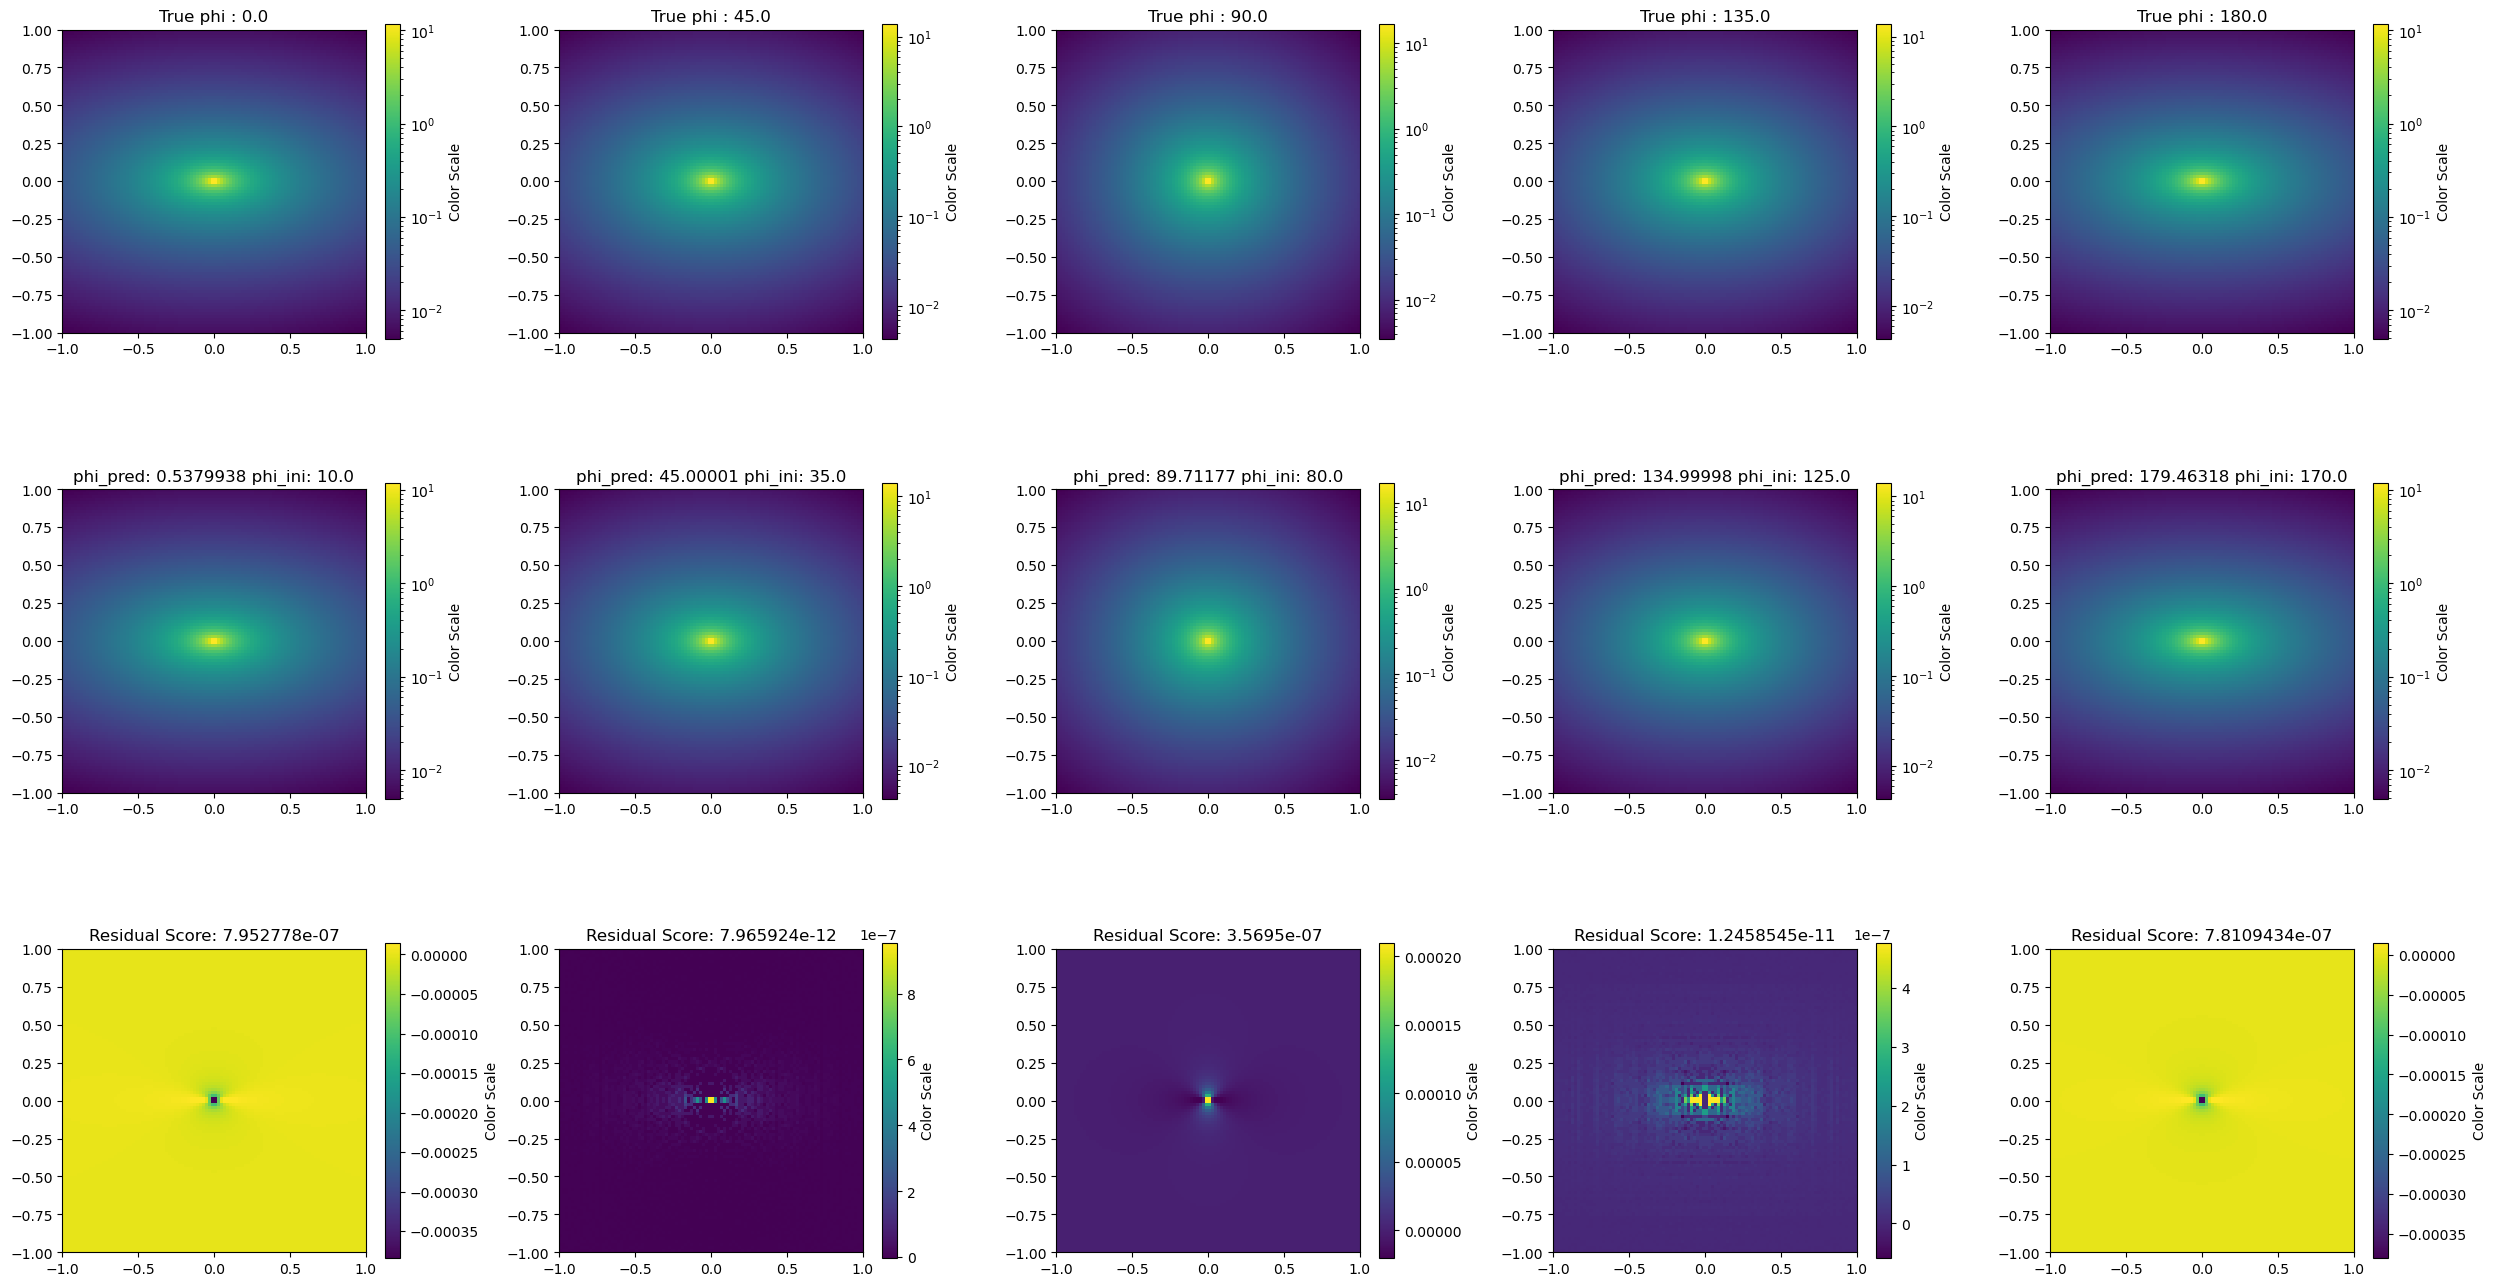

In [11]:
# varying over different p values

phi = [0.,45.,90.,135.,180.]

phi_guess = [10.,35.,80.,125.,170.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q_def, rho0_def, s_def, a_def, b_def, i_def, phi[j], theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True phi : "+str(phi[j]))

    bounds = (phi[0], phi[-1])
    starting_guess = phi_guess[j] #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,q_def,rho0_def,s_def,a_def,b_def,i_def,starting_guess,theta_def]
    optimize_mask = [False,False,False,False,False,False,False,False,True,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("phi_pred: "+str(res[-1])+" phi_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Optimzer route:  [Array(10., dtype=float32), Array(6.3329554, dtype=float32), Array(0., dtype=float32)]
Optimzer route:  [Array(35., dtype=float32), Array(37.792984, dtype=float32), Array(44.653015, dtype=float32), Array(44.991592, dtype=float32), Array(45.000008, dtype=float32)]
Optimzer route:  [Array(80., dtype=float32), Array(83.66702, dtype=float32), Array(90.732605, dtype=float32), Array(89.9817, dtype=float32), Array(90.000015, dtype=float32)]
Optimzer route:  [Array(125., dtype=float32), Array(127.792984, dtype=float32), Array(134.65295, dtype=float32), Array(134.99158, dtype=float32), Array(135., dtype=float32)]
Optimzer route:  [Array(170., dtype=float32), Array(173.66704, dtype=float32), Array(180., dtype=float32)]


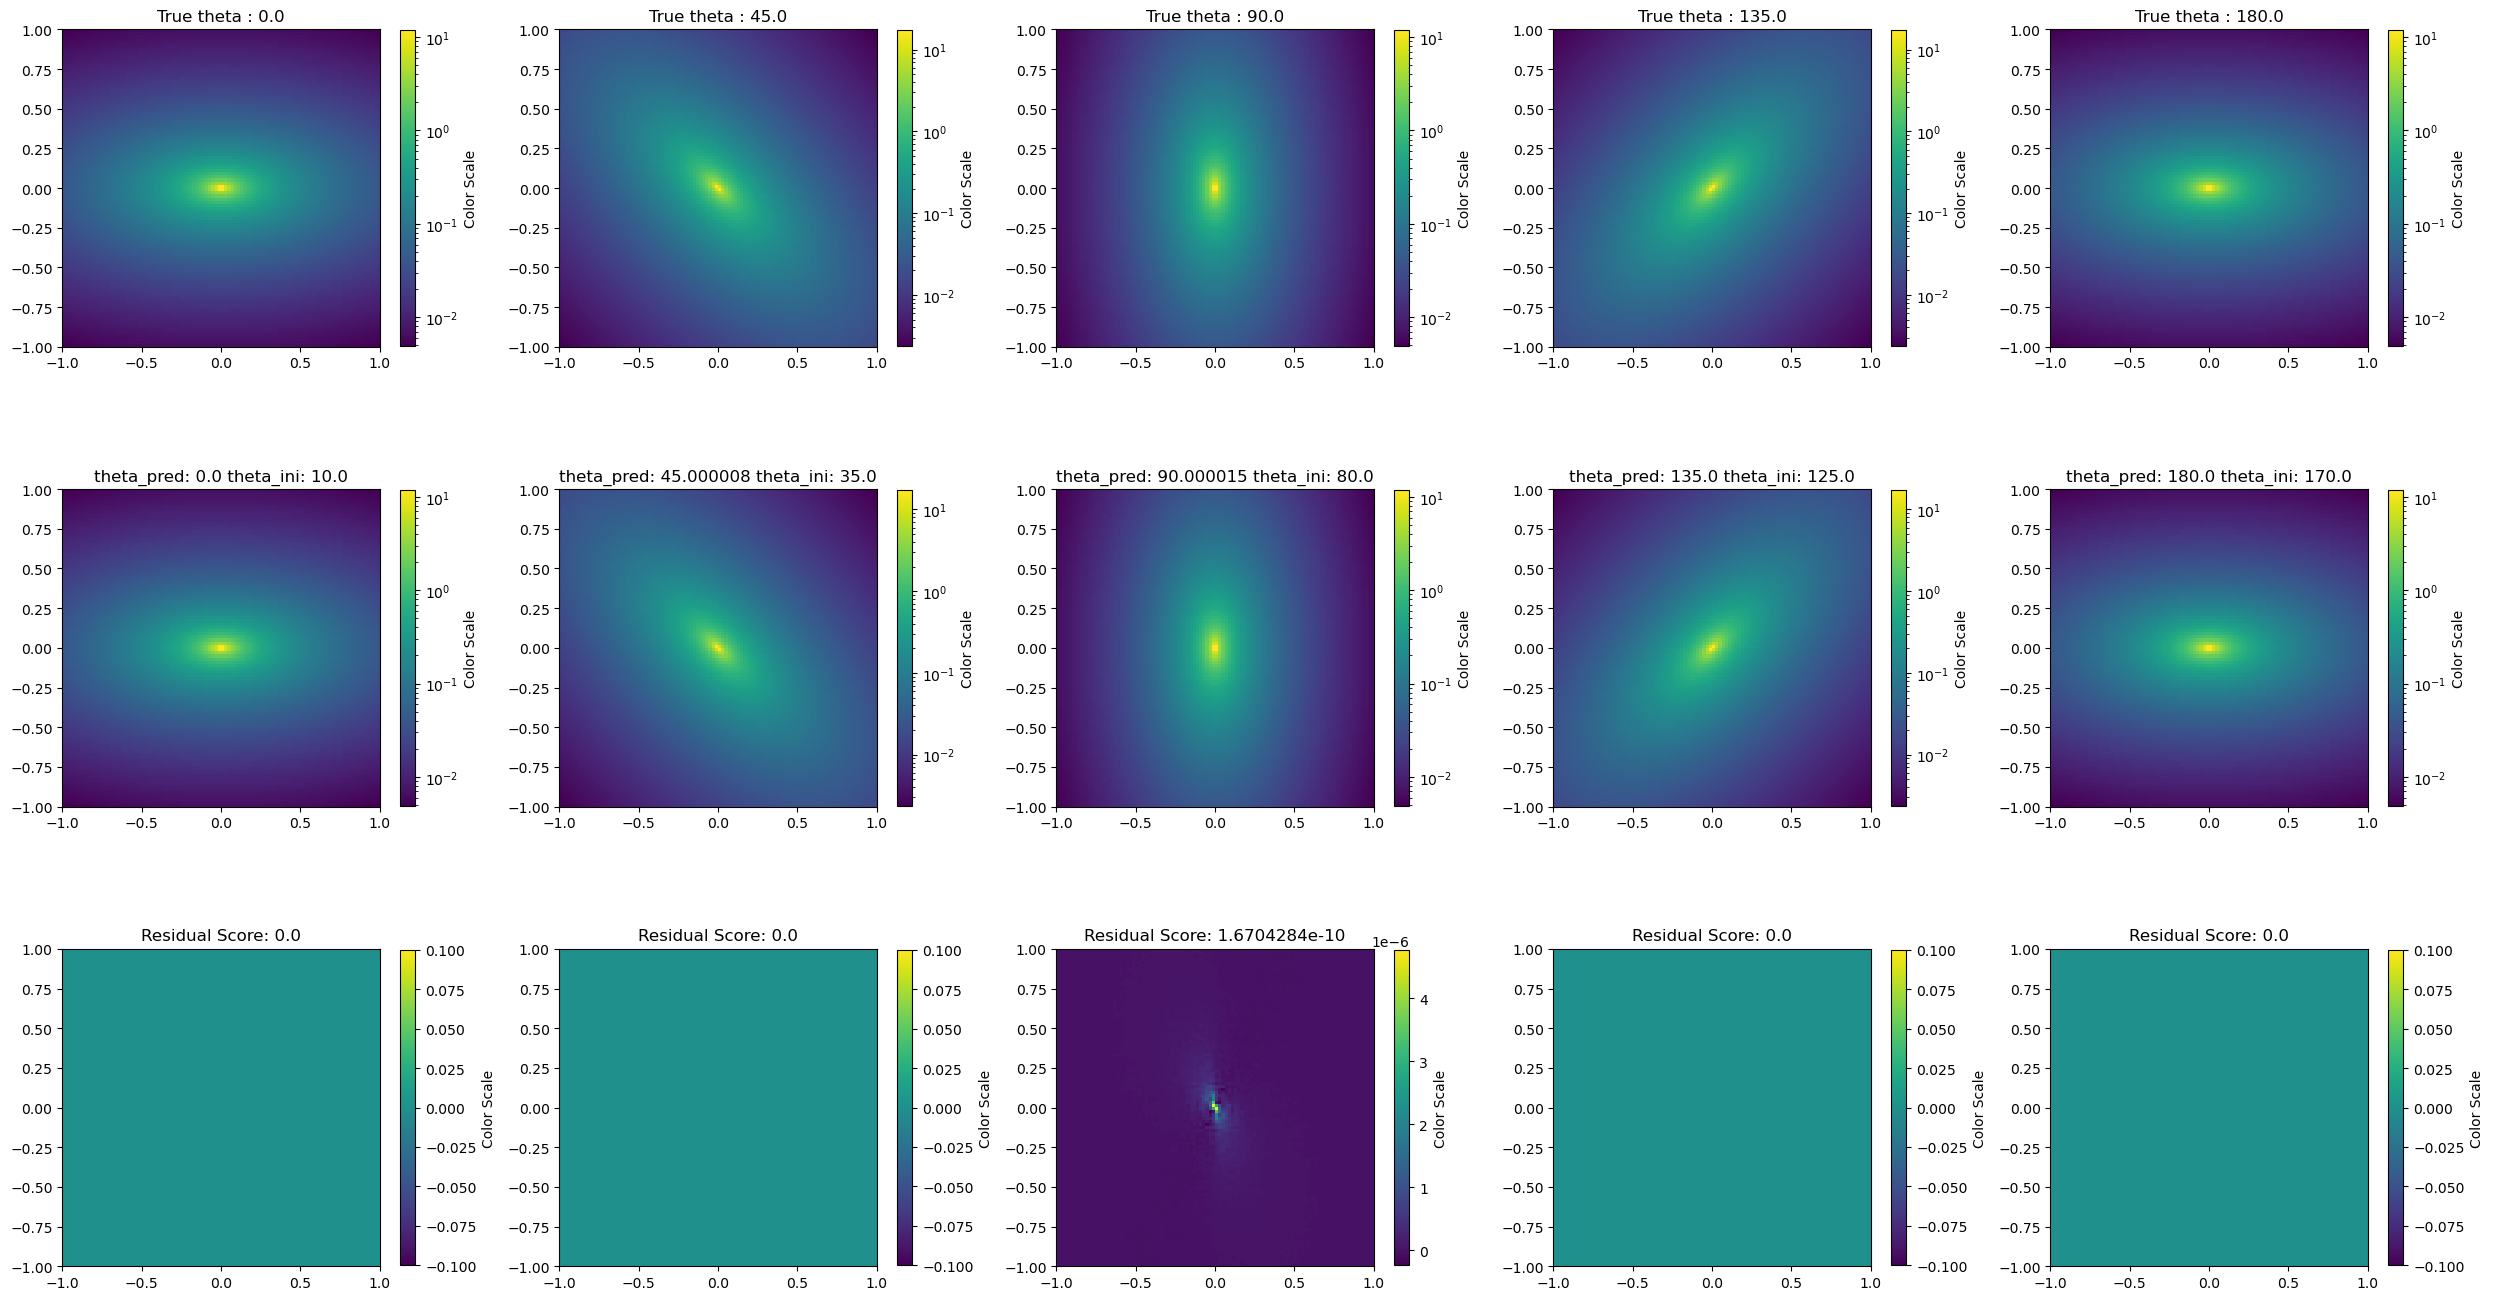

In [12]:
# varying over different p values

theta = [0.,45.,90.,135.,180.]

theta_guess = [10.,35.,80.,125.,170.]
# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p_def, q_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta[j])
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale',shrink=0.7)
    ax1.set_title("True theta : "+str(theta[j]))

    bounds = (theta[0], theta[-1])
    starting_guess = theta_guess[j] #random.uniform(p[0], p[-1])
    initial_params = [e_def,p_def,q_def,rho0_def,s_def,a_def,b_def,i_def,phi_def,starting_guess]
    optimize_mask = [False,False,False,False,False,False,False,False,False,True]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale',shrink=0.7)
    ax2.set_title("theta_pred: "+str(res[-1])+" theta_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale',shrink=0.7)
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()